In [1]:
import pandas as pd 
import numpy as np 

from upstream_oil_data import load_year, load_years ,drop_empty_observations, standardize_units


def mark_years_2025_2026(axes, *, color='#CBD5E1', alpha=0.22, text_color='#64748B'):
    """Shade and label 2025-2026 on notebook time-series charts."""
    if not isinstance(axes, (list, tuple, np.ndarray)):
        axes = [axes]
    spans = (
        (pd.Timestamp('2025-01-01'), pd.Timestamp('2026-01-01'), '2025'),
        (pd.Timestamp('2026-01-01'), pd.Timestamp('2027-01-01'), '2026'),
    )
    for ax in axes:
        for start, end, _label in spans:
            ax.axvspan(start, end, color=color, alpha=alpha, zorder=0)
        ymin, ymax = ax.get_ylim()
        y = ymax - 0.05 * (ymax - ymin if ymax != ymin else abs(ymax) or 1)
        for start, end, label in spans:
            mid = start + (end - start) / 2
            ax.text(mid, y, label, ha='center', va='top', fontsize=9, color=text_color)

year_list = [i for i in range(2002, 2027)]
oil_df = load_years(year_list) 
oil_df = drop_empty_observations(oil_df) 
oil_df = standardize_units(oil_df) 

country_code_path = r'data/jodi-oil-country-note.xlsx' 
sheet_name = 'Country names' 
# reading in the country code dataframe 
country_code_df = pd.read_excel(country_code_path, sheet_name=sheet_name)  

# mapping the country code to the country name
country_code_df = country_code_df[['NewName', 'Name']]
oil_df = oil_df.merge(country_code_df, left_on ='REF_AREA', right_on = 'NewName' )


In [2]:
# continent lookup for all countries in the dataset
continent_df = pd.read_csv('data/country_continents.csv')
oil_df = oil_df.merge(continent_df[['REF_AREA', 'continent']], on='REF_AREA', how='left')
continent_df

,REF_AREA,Name,continent
0,AE,United Arab Emirates,Asia
1,AL,Albania,Europe
2,AM,Armenia,Asia
3,AO,Angola,Africa
4,AR,Argentina,South America
...,...,...,...
113,UY,Uruguay,South America
114,VE,Venezuela,South America
115,VN,Vietnam,Asia
116,YE,Yemen,Asia


In [3]:
# listing common variables that we need 
stock_change = 'STOCKCH' 
demand = 'TOTDEMO' 
production = 'INDPROD' 
oil_receipts = 'RECEIPTS' 
imports = 'TOTIMPSB' 
exports = 'TOTEXPSB' 
month_end_stocks = 'CLOSTLV' 

# OPEC member countries (ISO 3166-1 alpha-2 codes used in REF_AREA)
opec_country_codes = [
    'DZ',  # Algeria
    'CG',  # Congo
    'GQ',  # Equatorial Guinea
    'GA',  # Gabon
    'IR',  # Iran
    'IQ',  # Iraq
    'KW',  # Kuwait
    'LY',  # Libya
    'NG',  # Nigeria
    'SA',  # Saudi Arabia
    'AE',  # United Arab Emirates
    'VE',  # Venezuela
]

# OPEC members that appear in this JODI dataset
opec_in_dataset = [code for code in opec_country_codes if code in oil_df['REF_AREA'].unique()]
opec_in_dataset
 

['DZ', 'GQ', 'GA', 'IR', 'IQ', 'KW', 'LY', 'NG', 'SA', 'AE', 'VE']

In [4]:
# arranging by time 
oil_df['TIME_PERIOD'] = pd.to_datetime(oil_df['TIME_PERIOD'])
# standardizing the country names 
oil_df['Name'] = oil_df['Name'].str.lower()
oil_df = oil_df.sort_values('TIME_PERIOD')
oil_df

,REF_AREA,TIME_PERIOD,ENERGY_PRODUCT,FLOW_BREAKDOWN,OBS_VALUE,SOURCE_UNIT,ASSESSMENT_CODE,DAYS_IN_MONTH,NewName,Name,continent
0,AE,2002-01-01,CRUDEOIL,INDPROD,60605.0,KBBL,1.0,31,AE,united arab emirates,Asia
151022,CU,2002-01-01,CRUDEOIL,STOCKCH,0.0,KBBL,3.0,31,CU,cuba,North America
151021,CU,2002-01-01,CRUDEOIL,REFINOBS,0.0,KBBL,3.0,31,CU,cuba,North America
151020,CU,2002-01-01,CRUDEOIL,INDPROD,2022.0,KBBL,1.0,31,CU,cuba,North America
151019,CU,2002-01-01,CRUDEOIL,CLOSTLV,0.0,KBBL,3.0,31,CU,cuba,North America
...,...,...,...,...,...,...,...,...,...,...,...
436679,LV,2026-04-01,OTHERCRUDE,CLOSTLV,0.0,KBBL,1.0,30,LV,latvia,Europe
436680,LV,2026-04-01,OTHERCRUDE,INDPROD,0.0,KBBL,1.0,30,LV,latvia,Europe
436681,LV,2026-04-01,OTHERCRUDE,INDPROD,0.0,KBBL,1.0,30,LV,latvia,Europe
436672,LV,2026-04-01,NGL,STOCKCH,0.0,KBBL,1.0,30,LV,latvia,Europe


In [5]:
# creating a global series for production of oil
production_raw = oil_df[oil_df['FLOW_BREAKDOWN'] == production].copy()

# From Jan 2009 JODI adds NGL, OTHERCRUDE, and TOTCRUDE alongside CRUDEOIL.
# TOTCRUDE is the total — summing all product rows double-counts production.
prod_by_type = production_raw.pivot_table(
    index=['REF_AREA', 'TIME_PERIOD'],
    columns='ENERGY_PRODUCT',
    values='OBS_VALUE',
    aggfunc='first',
)
production_df = (
    prod_by_type.assign(
        OBS_VALUE=prod_by_type['TOTCRUDE'].fillna(prod_by_type['CRUDEOIL'])
    )
    .reset_index()
    .dropna(subset=['OBS_VALUE'])
)

meta_cols = ['REF_AREA', 'TIME_PERIOD', 'Name', 'continent', 'NewName']
production_df = production_df.merge(
    production_raw[meta_cols].drop_duplicates(),
    on=['REF_AREA', 'TIME_PERIOD'],
    how='left',
)
production_df['is_opec'] = production_df['REF_AREA'].isin(opec_in_dataset)

glob_month_prod = production_df.groupby('TIME_PERIOD')['OBS_VALUE'].sum()
opec_group_prod = production_df.groupby(['TIME_PERIOD', 'is_opec'])['OBS_VALUE'].sum()

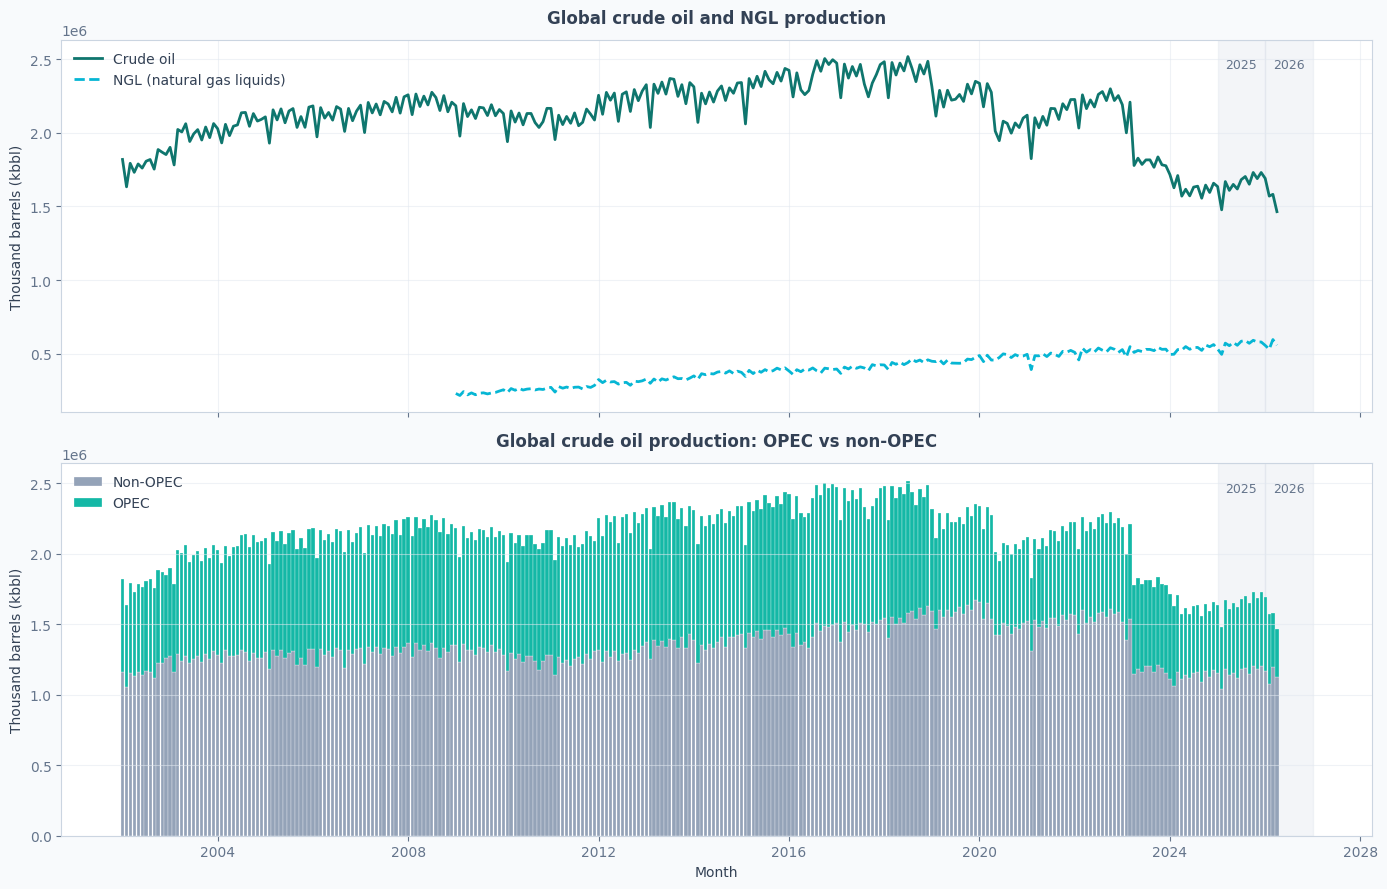

In [6]:
import matplotlib.pyplot as plt

# NGL = natural gas liquids (closest JODI primary-table proxy for nat-gas-related output)
ngl_month_prod = (
    oil_df[(oil_df['FLOW_BREAKDOWN'] == production) & (oil_df['ENERGY_PRODUCT'] == 'NGL')]
    .groupby('TIME_PERIOD')['OBS_VALUE']
    .sum()
)

opec_wide = opec_group_prod.unstack('is_opec').fillna(0)
opec_wide.columns = ['Non-OPEC', 'OPEC']

# Teal / cyan / grey business palette
COLORS = {
    'crude': '#0F766E',
    'ngl': '#06B6D4',
    'non_opec': '#94A3B8',
    'opec': '#14B8A6',
    'bg': '#F8FAFC',
    'panel': '#FFFFFF',
    'text': '#334155',
    'muted': '#64748B',
    'grid': '#E2E8F0',
}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor': COLORS['panel'],
    'axes.edgecolor': '#CBD5E1',
    'axes.labelcolor': COLORS['text'],
    'axes.titlecolor': COLORS['text'],
    'text.color': COLORS['text'],
    'xtick.color': COLORS['muted'],
    'ytick.color': COLORS['muted'],
    'grid.color': COLORS['grid'],
    'legend.frameon': False,
    'font.size': 10,
})

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.patch.set_facecolor(COLORS['bg'])

axes[0].plot(
    glob_month_prod.index,
    glob_month_prod.values,
    color=COLORS['crude'],
    linewidth=2.0,
    label='Crude oil',
)
axes[0].plot(
    ngl_month_prod.index,
    ngl_month_prod.values,
    color=COLORS['ngl'],
    linewidth=2.0,
    linestyle='--',
    label='NGL (natural gas liquids)',
)
axes[0].set_title('Global crude oil and NGL production', fontweight='600', pad=12)
axes[0].set_ylabel('Thousand barrels (kbbl)')
axes[0].grid(True, alpha=0.55, linewidth=0.8)
axes[0].legend(loc='upper left')

axes[1].bar(
    opec_wide.index,
    opec_wide['Non-OPEC'],
    width=25,
    label='Non-OPEC',
    color=COLORS['non_opec'],
    edgecolor='white',
    linewidth=0.2,
)
axes[1].bar(
    opec_wide.index,
    opec_wide['OPEC'],
    width=25,
    bottom=opec_wide['Non-OPEC'],
    label='OPEC',
    color=COLORS['opec'],
    edgecolor='white',
    linewidth=0.2,
)
axes[1].set_title('Global crude oil production: OPEC vs non-OPEC', fontweight='600', pad=12)
axes[1].set_ylabel('Thousand barrels (kbbl)')
axes[1].legend(loc='upper left')
axes[1].grid(True, axis='y', alpha=0.55, linewidth=0.8)

mark_years_2025_2026(axes)

plt.xlabel('Month')
plt.tight_layout()
plt.show()

In [7]:
# looking at month-end stocks (CLOSTLV = closing inventory, not geological reserves)
month_stocks_df = oil_df[oil_df['FLOW_BREAKDOWN'] == month_end_stocks]
month_stocks_pivot = month_stocks_df.pivot_table(
    index=['REF_AREA', 'TIME_PERIOD'],
    columns='ENERGY_PRODUCT',
    values='OBS_VALUE',
    aggfunc='first',
)
tot_crude = month_stocks_pivot['TOTCRUDE'] if 'TOTCRUDE' in month_stocks_pivot.columns else np.nan
crude = month_stocks_pivot['CRUDEOIL'] if 'CRUDEOIL' in month_stocks_pivot.columns else np.nan
month_stocks_pivot = month_stocks_pivot.assign(OBS_VALUE=tot_crude.fillna(crude))
month_stocks_pivot = month_stocks_pivot.reset_index().dropna(subset=['OBS_VALUE'])
global_stocks = month_stocks_pivot.groupby('TIME_PERIOD')['OBS_VALUE'].sum()

# monthly stock change (STOCKCH)
stock_change_df = oil_df[oil_df['FLOW_BREAKDOWN'] == stock_change]
stock_change_pivot = stock_change_df.pivot_table(
    index=['REF_AREA', 'TIME_PERIOD'],
    columns='ENERGY_PRODUCT',
    values='OBS_VALUE',
    aggfunc='first',
)
tot_crude = stock_change_pivot['TOTCRUDE'] if 'TOTCRUDE' in stock_change_pivot.columns else np.nan
crude = stock_change_pivot['CRUDEOIL'] if 'CRUDEOIL' in stock_change_pivot.columns else np.nan
stock_change_pivot = stock_change_pivot.assign(OBS_VALUE=tot_crude.fillna(crude))
stock_change_pivot = stock_change_pivot.reset_index().dropna(subset=['OBS_VALUE'])
global_stock_change = stock_change_pivot.groupby('TIME_PERIOD')['OBS_VALUE'].sum()

# demand: TOTDEMO is not in this JODI extract; use refinery intake (REFINOBS)
demand_df = oil_df[oil_df['FLOW_BREAKDOWN'] == 'REFINOBS']
demand_pivot = demand_df.pivot_table(
    index=['REF_AREA', 'TIME_PERIOD'],
    columns='ENERGY_PRODUCT',
    values='OBS_VALUE',
    aggfunc='first',
)
tot_crude = demand_pivot['TOTCRUDE'] if 'TOTCRUDE' in demand_pivot.columns else np.nan
crude = demand_pivot['CRUDEOIL'] if 'CRUDEOIL' in demand_pivot.columns else np.nan
demand_pivot = demand_pivot.assign(OBS_VALUE=tot_crude.fillna(crude))
demand_pivot = demand_pivot.reset_index().dropna(subset=['OBS_VALUE'])
global_demand = demand_pivot.groupby('TIME_PERIOD')['OBS_VALUE'].sum()


In [8]:
# detrending the refinery intake
from statsmodels.tsa.seasonal import seasonal_decompose

demand_ts = global_demand.sort_index().asfreq('MS')
decomp_demand = seasonal_decompose(
    demand_ts,
    model='multiplicative',
    period=12,
    extrapolate_trend='freq',  # avoids NaN residuals at series endpoints
)
det_glob_demand = decomp_demand.resid
det_glob_demand

TIME_PERIOD
2002-01-01    1.015907
2002-02-01    1.013634
2002-03-01    1.005773
2002-04-01    1.024174
2002-05-01    1.003670
                ...   
2025-12-01    1.031734
2026-01-01    0.996449
2026-02-01    0.977501
2026-03-01    0.956417
2026-04-01    0.901744
Freq: MS, Name: resid, Length: 292, dtype: float64

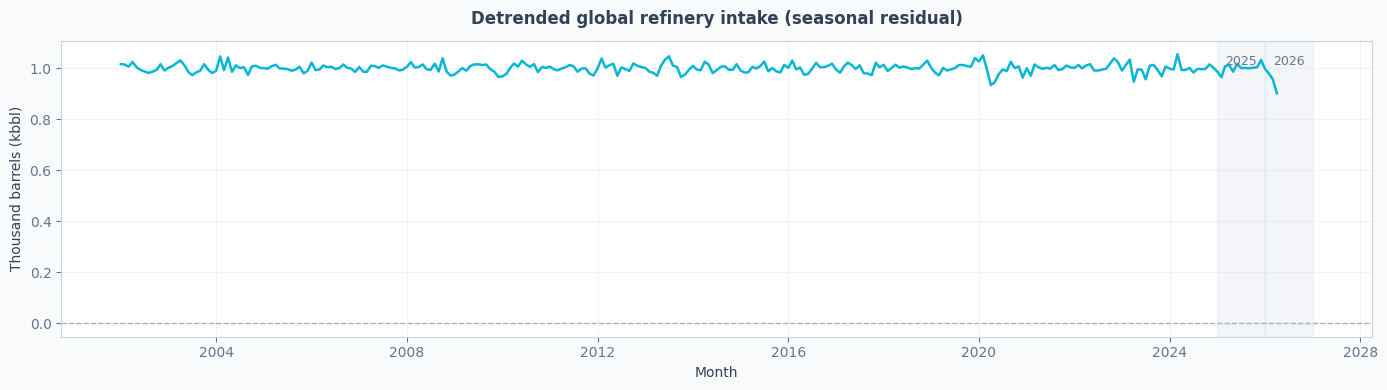

In [9]:
import matplotlib.pyplot as plt

COLORS = {
    'resid': '#06B6D4',
    'zero': '#94A3B8',
    'bg': '#F8FAFC',
    'panel': '#FFFFFF',
    'text': '#334155',
    'muted': '#64748B',
    'grid': '#E2E8F0',
}

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])

ax.plot(det_glob_demand.index, det_glob_demand.values, color=COLORS['resid'], linewidth=1.8)
ax.axhline(0, color=COLORS['zero'], linewidth=1.0, linestyle='--', alpha=0.8)
ax.set_title('Detrended global refinery intake (seasonal residual)', fontweight='600', pad=12)
ax.set_ylabel('Thousand barrels (kbbl)')
ax.set_xlabel('Month')
ax.grid(True, alpha=0.55, linewidth=0.8)

mark_years_2025_2026(ax)

plt.tight_layout()
plt.show()

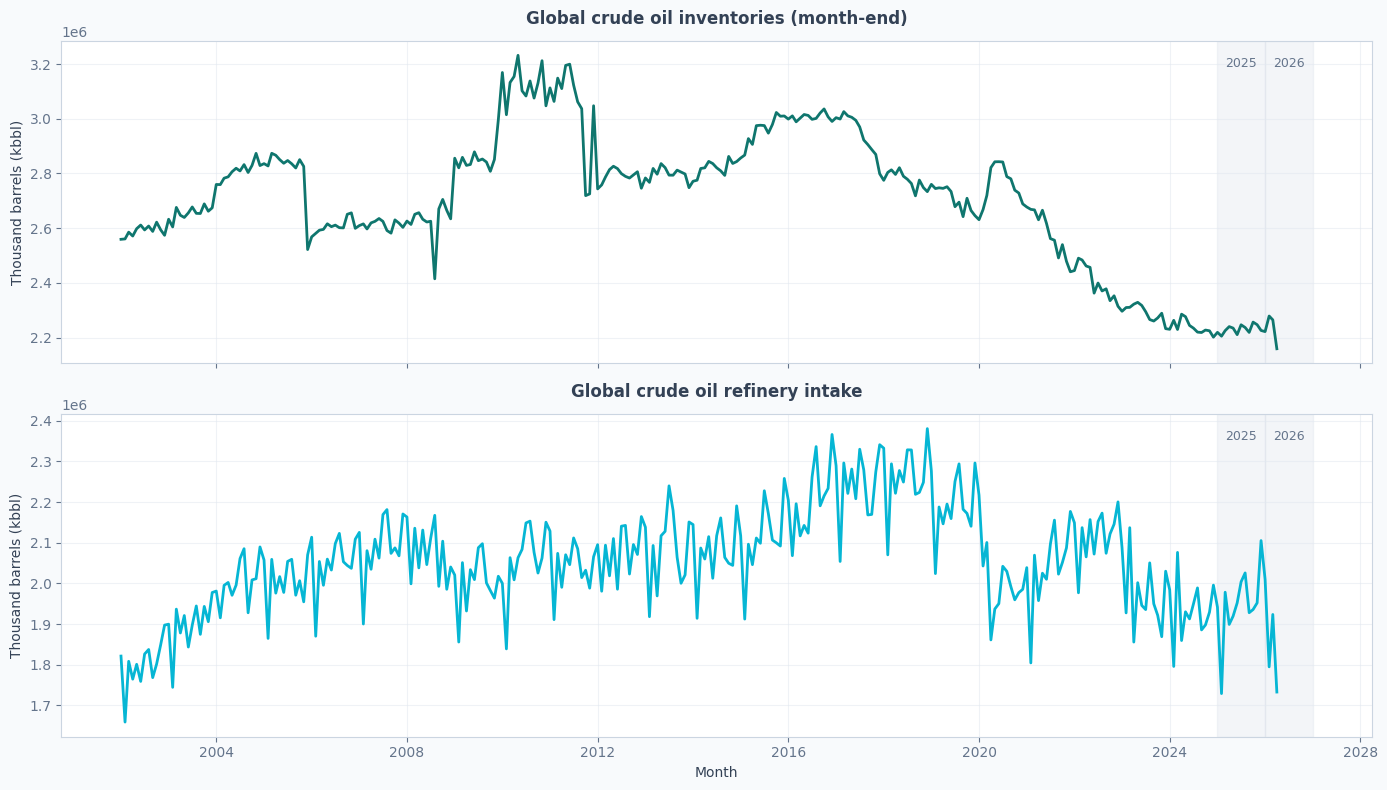

In [10]:
import matplotlib.pyplot as plt

COLORS = {
    'stocks': '#0F766E',
    'demand': '#06B6D4',
    'bg': '#F8FAFC',
    'panel': '#FFFFFF',
    'text': '#334155',
    'muted': '#64748B',
    'grid': '#E2E8F0',
}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor': COLORS['panel'],
    'axes.edgecolor': '#CBD5E1',
    'axes.labelcolor': COLORS['text'],
    'axes.titlecolor': COLORS['text'],
    'text.color': COLORS['text'],
    'xtick.color': COLORS['muted'],
    'ytick.color': COLORS['muted'],
    'grid.color': COLORS['grid'],
    'legend.frameon': False,
    'font.size': 10,
})

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor(COLORS['bg'])

axes[0].plot(
    global_stocks.index,
    global_stocks.values,
    color=COLORS['stocks'],
    linewidth=2.0,
    label='Month-end stocks',
)
axes[0].set_title('Global crude oil inventories (month-end)', fontweight='600', pad=12)
axes[0].set_ylabel('Thousand barrels (kbbl)')
axes[0].grid(True, alpha=0.55, linewidth=0.8)

axes[1].plot(
    global_demand.index,
    global_demand.values,
    color=COLORS['demand'],
    linewidth=2.0,
    label='Refinery intake (demand proxy)',
)
axes[1].set_title('Global crude oil refinery intake', fontweight='600', pad=12)
axes[1].set_ylabel('Thousand barrels (kbbl)')
axes[1].grid(True, alpha=0.55, linewidth=0.8)

mark_years_2025_2026(axes)

plt.xlabel('Month')
plt.tight_layout()
plt.show()

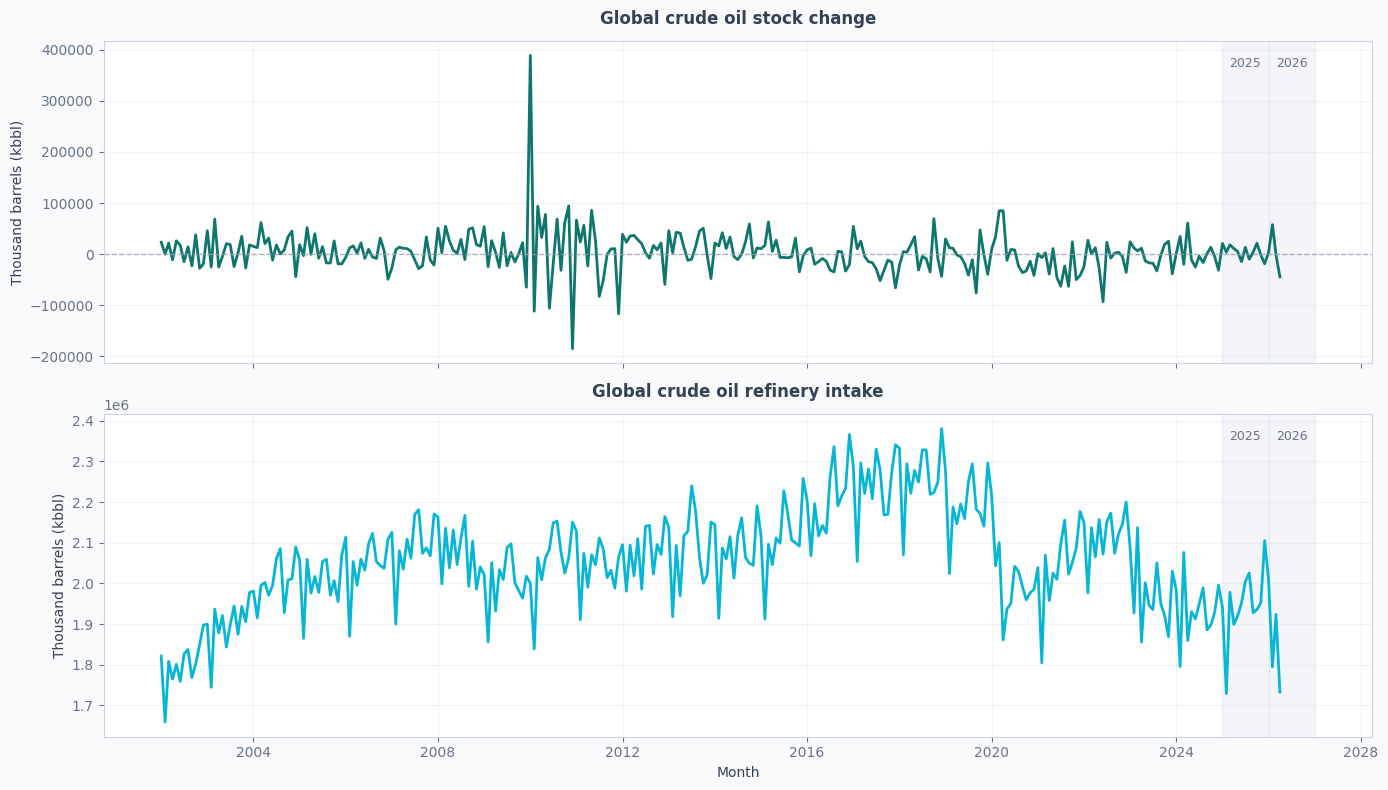

In [11]:
import matplotlib.pyplot as plt

COLORS = {
    'stock_change': '#0F766E',
    'demand': '#06B6D4',
    'zero': '#94A3B8',
    'bg': '#F8FAFC',
    'panel': '#FFFFFF',
    'text': '#334155',
    'muted': '#64748B',
    'grid': '#E2E8F0',
}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor': COLORS['panel'],
    'axes.edgecolor': '#CBD5E1',
    'axes.labelcolor': COLORS['text'],
    'axes.titlecolor': COLORS['text'],
    'text.color': COLORS['text'],
    'xtick.color': COLORS['muted'],
    'ytick.color': COLORS['muted'],
    'grid.color': COLORS['grid'],
    'legend.frameon': False,
    'font.size': 10,
})

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor(COLORS['bg'])

axes[0].plot(
    global_stock_change.index,
    global_stock_change.values,
    color=COLORS['stock_change'],
    linewidth=2.0,
    label='Monthly stock change',
)
axes[0].axhline(0, color=COLORS['zero'], linewidth=1.0, linestyle='--', alpha=0.8)
axes[0].set_title('Global crude oil stock change', fontweight='600', pad=12)
axes[0].set_ylabel('Thousand barrels (kbbl)')
axes[0].grid(True, alpha=0.55, linewidth=0.8)

axes[1].plot(
    global_demand.index,
    global_demand.values,
    color=COLORS['demand'],
    linewidth=2.0,
    label='Refinery intake (demand proxy)',
)
axes[1].set_title('Global crude oil refinery intake', fontweight='600', pad=12)
axes[1].set_ylabel('Thousand barrels (kbbl)')
axes[1].grid(True, alpha=0.55, linewidth=0.8)

mark_years_2025_2026(axes)

plt.xlabel('Month')
plt.tight_layout()
plt.show()

In [12]:
# detrending global stock change
from statsmodels.tsa.seasonal import seasonal_decompose

stock_change_ts = global_stock_change.sort_index().asfreq('MS')
decomp_stock_change = seasonal_decompose(
    stock_change_ts,
    model='additive',
    period=12,
    extrapolate_trend='freq',
)
det_glob_stock_change = decomp_stock_change.resid
det_glob_stock_change

TIME_PERIOD
2002-01-01   -11819.957226
2002-02-01    -7535.236644
2002-03-01    -9962.917778
2002-04-01   -21352.732561
2002-05-01    10722.351823
                  ...     
2025-12-01    16750.803355
2026-01-01   -36379.469797
2026-02-01    45838.581135
2026-03-01   -38443.428650
2026-04-01   -60351.107084
Freq: MS, Name: resid, Length: 292, dtype: float64

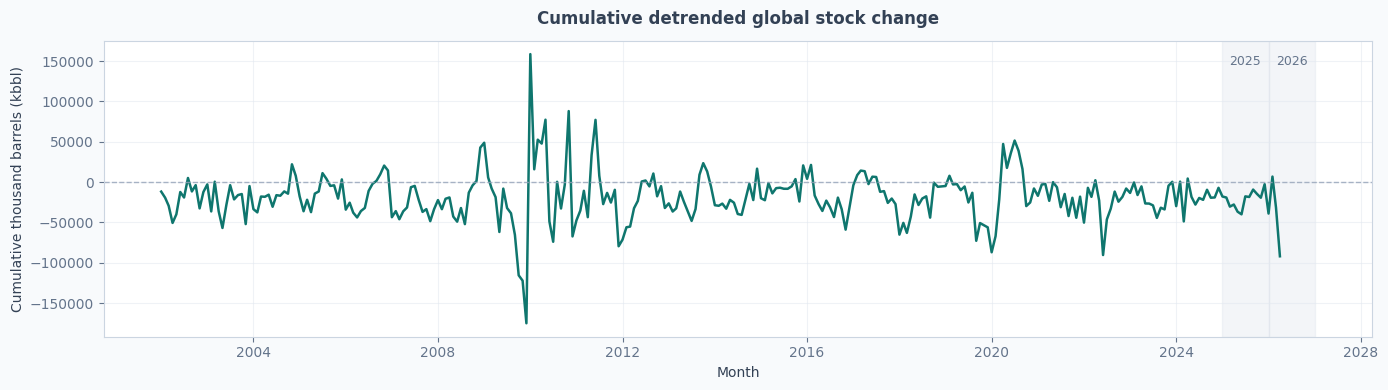

In [13]:
import matplotlib.pyplot as plt

COLORS = {
    'resid': '#0F766E',
    'zero': '#94A3B8',
    'bg': '#F8FAFC',
    'panel': '#FFFFFF',
    'text': '#334155',
    'muted': '#64748B',
    'grid': '#E2E8F0',
}

det_glob_stock_change_cum = det_glob_stock_change.cumsum()

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])

ax.plot(
    det_glob_stock_change_cum.index,
    det_glob_stock_change_cum.values,
    color=COLORS['resid'],
    linewidth=1.8,
)
ax.axhline(0, color=COLORS['zero'], linewidth=1.0, linestyle='--', alpha=0.8)
ax.set_title('Cumulative detrended global stock change', fontweight='600', pad=12)
ax.set_ylabel('Cumulative thousand barrels (kbbl)')
ax.set_xlabel('Month')
ax.grid(True, alpha=0.55, linewidth=0.8)

mark_years_2025_2026(ax)

plt.tight_layout()
plt.show()

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

continent_df = pd.read_csv('data/country_continents.csv')
demand_continent = stock_change_pivot.merge(continent_df, on='REF_AREA', how='left')

# pivoting across continents
demand_continent = demand_continent.pivot_table(
    index='TIME_PERIOD',
    columns='continent',
    values='OBS_VALUE',
    aggfunc='sum',
)

def detrend_series(series: pd.Series) -> pd.Series:
    """Seasonal decomposition for one continent; returns residuals."""
    ts = series.sort_index()
    ts.index = pd.to_datetime(ts.index)
    ts = ts.asfreq('MS')
    result = seasonal_decompose(
        ts,
        model='additive',
        period=12,
        extrapolate_trend='freq',
    )
    return result.resid

# seasonal_decompose needs a 1D series — apply per continent column
demand_continent_detrend = demand_continent.apply(detrend_series)
demand_continent_detrend




continent,Africa,Asia,Europe,North America,Oceania,South America
TIME_PERIOD,,,,,,
2002-01-01,-12578.196327,-10786.732996,14963.838089,-2453.589181,-2134.832147,1169.555336
2002-02-01,5123.736158,-14309.949884,-11593.779088,7576.037212,3392.043348,2276.675609
2002-03-01,-1039.824289,10446.886443,-10515.855196,-4028.138211,-2529.524024,-2296.462500
2002-04-01,670.188163,-14792.033972,-7798.536695,-615.187367,-276.747913,1459.585223
2002-05-01,-7954.273746,-564.173118,11693.892462,2750.678667,-1036.930998,5833.158556
...,...,...,...,...,...,...
2025-12-01,8650.033013,12518.176946,-1553.143286,-4867.895619,1163.726578,839.905722
2026-01-01,-8732.737202,477.718673,-9255.099586,-17647.584391,-483.050538,-738.716752
2026-02-01,5645.634654,7106.836454,12525.191391,19114.063076,-689.764239,2136.619799


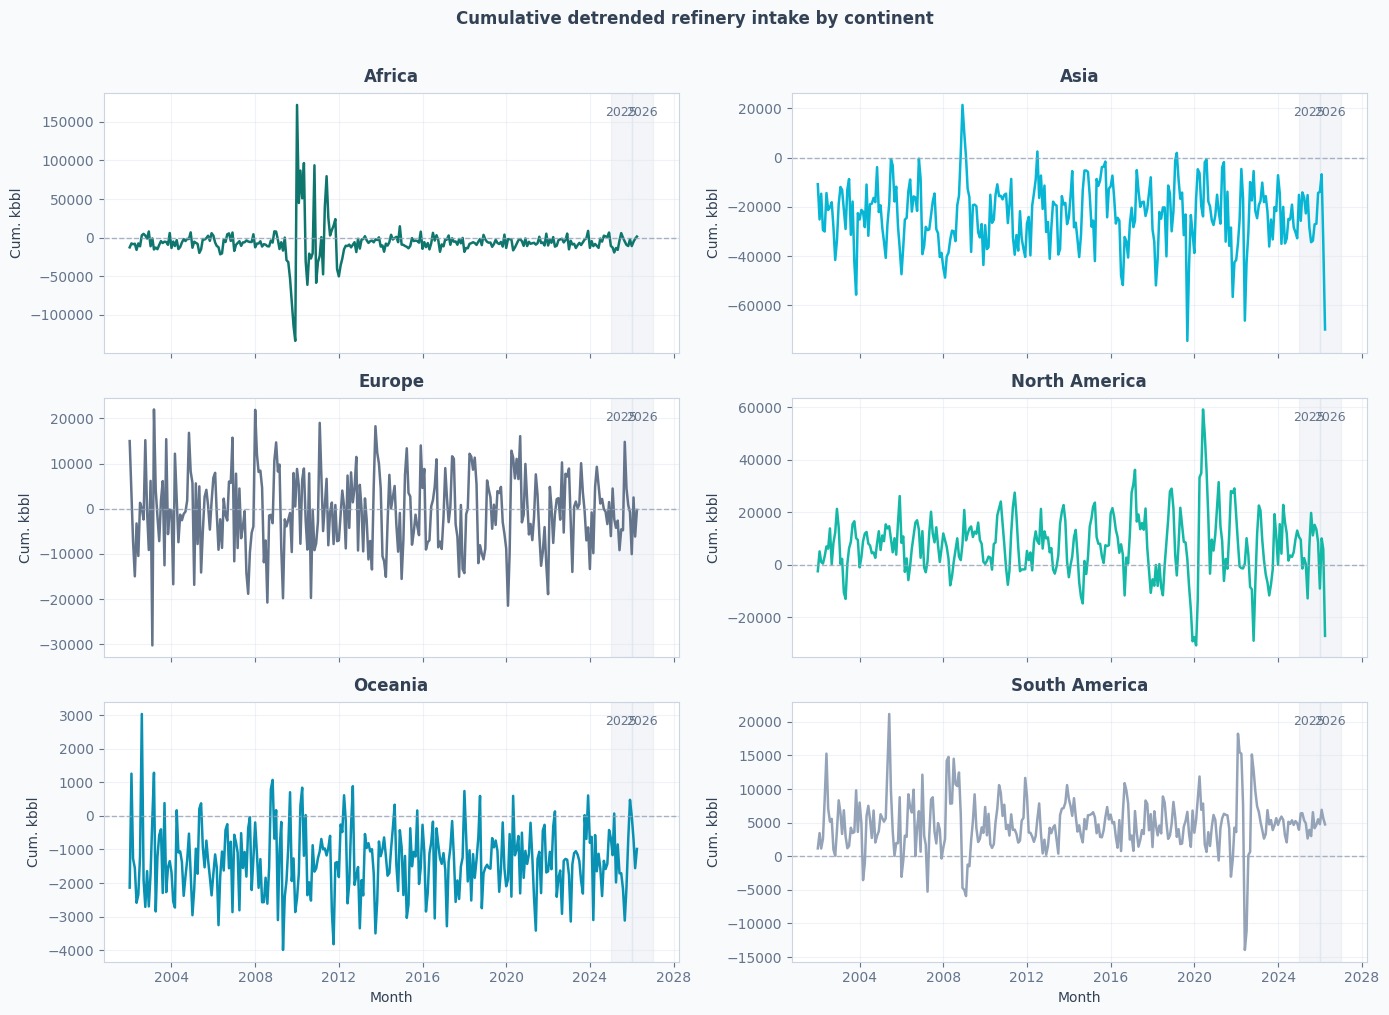

In [15]:
import matplotlib.pyplot as plt

COLORS = {
    'resid': '#0F766E',
    'zero': '#94A3B8',
    'bg': '#F8FAFC',
    'panel': '#FFFFFF',
    'text': '#334155',
    'muted': '#64748B',
    'grid': '#E2E8F0',
}
CONTINENT_COLORS = {
    'Africa': '#0F766E',
    'Asia': '#06B6D4',
    'Europe': '#64748B',
    'North America': '#14B8A6',
    'Oceania': '#0891B2',
    'South America': '#94A3B8',
}

demand_continent_detrend_cum = demand_continent_detrend.cumsum()
continents = list(demand_continent_detrend_cum.columns)

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
fig.patch.set_facecolor(COLORS['bg'])

for ax, continent in zip(axes.flat, continents):
    ax.set_facecolor(COLORS['panel'])
    ax.plot(
        demand_continent_detrend_cum.index,
        demand_continent_detrend_cum[continent],
        color=CONTINENT_COLORS.get(continent, COLORS['resid']),
        linewidth=1.8,
    )
    ax.axhline(0, color=COLORS['zero'], linewidth=1.0, linestyle='--', alpha=0.8)
    ax.set_title(continent, fontweight='600', pad=8)
    ax.set_ylabel('Cum. kbbl')
    ax.grid(True, alpha=0.55, linewidth=0.8)
    mark_years_2025_2026(ax)

for ax in axes[-1]:
    ax.set_xlabel('Month')

fig.suptitle(
    'Cumulative detrended refinery intake by continent',
    fontweight='600',
    y=1.01,
    color=COLORS['text'],
)
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from macro_data import (
    load_brent_monthly,
    load_kilian_igrea,
    load_cpb_industrial_production,
    load_imf_cpi_index,
    load_imf_cpi_yoy,
    load_macro_panel,      # all series joined on month
    refresh_macro_files,   # re-download everything
)
ip = load_cpb_industrial_production()
cpi_index = load_imf_cpi_index() 
brent_monthly = load_brent_monthly() 
kilian_igrea = load_kilian_igrea() 

In [17]:
# oil production series 
global_production = production_df.groupby('TIME_PERIOD')['OBS_VALUE'].sum()  
global_production

TIME_PERIOD
2002-01-01    1819287.709
2002-02-01    1633453.901
2002-03-01    1793111.098
2002-04-01    1731722.097
2002-05-01    1788757.898
                 ...     
2025-12-01    1730642.841
2026-01-01    1690797.425
2026-02-01    1570405.133
2026-03-01    1582361.740
2026-04-01    1464654.771
Name: OBS_VALUE, Length: 292, dtype: float64

In [18]:
# Cholesky order: production → brent → ip → cpi
VAR_ORDER = ['production', 'brent', 'ip', 'cpi']

# standardizing to real price of oil 
world_cpi = cpi_index['world']
brent_real = brent_monthly / (world_cpi / 100)
brent_real = brent_real.dropna() 

# assmebling the data dataframe for SVAR 
world_panel = pd.DataFrame({
    'production': global_production,
    'brent': brent_real,
    'ip': ip['world'], 
    'cpi': cpi_index['world'],
})[VAR_ORDER]
world_panel = np.log(world_panel.dropna())

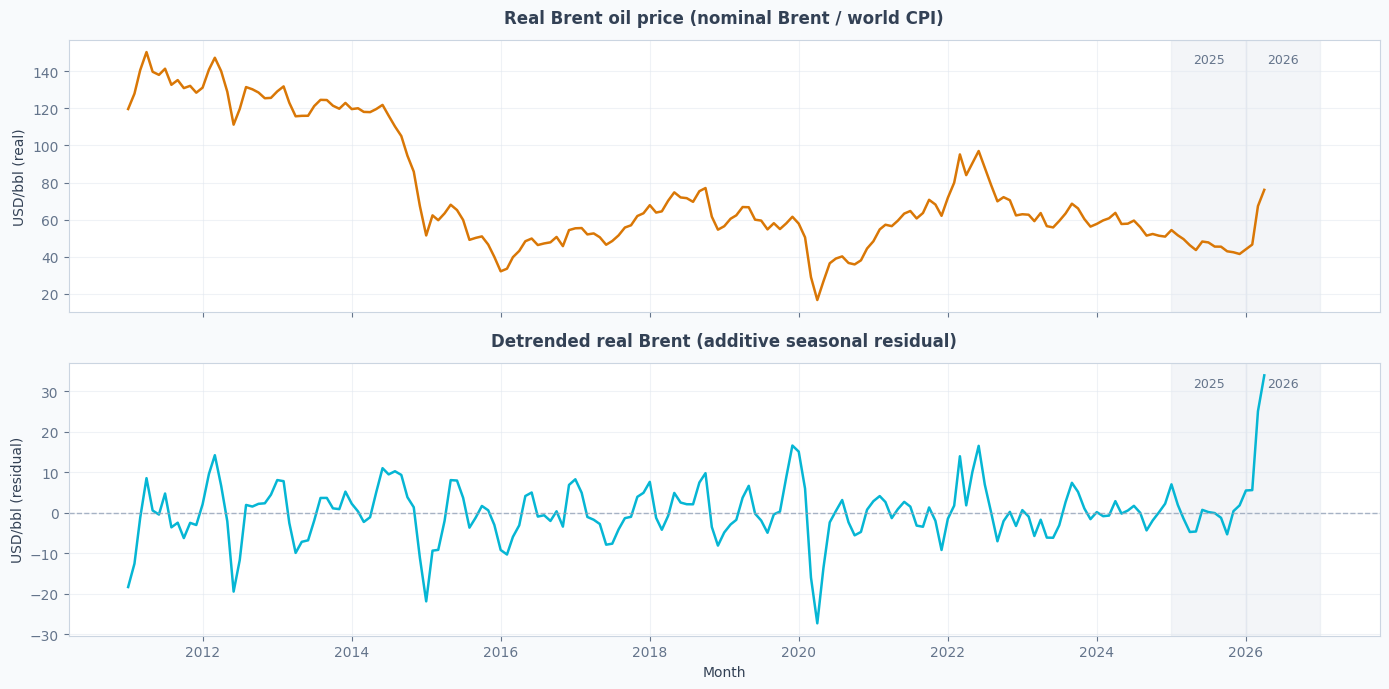

In [66]:
# Detrend and remove seasonality from real Brent (nominal Brent / world CPI)
from statsmodels.tsa.seasonal import seasonal_decompose

brent_real_ts = brent_real.sort_index().asfreq('MS')
decomp_brent_real = seasonal_decompose(
    brent_real_ts,
    model='additive',
    period=12,
    extrapolate_trend='freq',
)
det_brent_real = decomp_brent_real.resid.dropna()

COLORS = {
    'level': '#D97706',
    'resid': '#06B6D4',
    'zero': '#94A3B8',
    'bg': '#F8FAFC',
    'panel': '#FFFFFF',
    'text': '#334155',
    'muted': '#64748B',
    'grid': '#E2E8F0',
}

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.patch.set_facecolor(COLORS['bg'])

axes[0].set_facecolor(COLORS['panel'])
axes[0].plot(brent_real_ts.index, brent_real_ts.values, color=COLORS['level'], linewidth=1.8)
axes[0].set_title('Real Brent oil price (nominal Brent / world CPI)', fontweight='600', pad=12, color=COLORS['text'])
axes[0].set_ylabel('USD/bbl (real)')
axes[0].grid(True, alpha=0.55, linewidth=0.8, color=COLORS['grid'])

axes[1].set_facecolor(COLORS['panel'])
axes[1].plot(det_brent_real.index, det_brent_real.values, color=COLORS['resid'], linewidth=1.8)
axes[1].axhline(0, color=COLORS['zero'], linewidth=1.0, linestyle='--', alpha=0.8)
axes[1].set_title(
    'Detrended real Brent (additive seasonal residual)',
    fontweight='600',
    pad=12,
    color=COLORS['text'],
)
axes[1].set_ylabel('USD/bbl (residual)')
axes[1].set_xlabel('Month')
axes[1].grid(True, alpha=0.55, linewidth=0.8, color=COLORS['grid'])

mark_years_2025_2026(axes)

plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,missing
production,182.0,14.571,0.131,14.206,14.533,14.614,14.662,14.739,-1.065,0.042,0
brent,182.0,4.221,0.417,2.816,3.940,4.127,4.570,5.013,0.196,-0.301,0
ip,182.0,4.567,0.062,4.407,4.518,4.576,4.627,4.682,-0.122,-1.067,0
cpi,182.0,4.676,0.183,4.391,4.527,4.644,4.830,5.025,0.413,-1.015,0


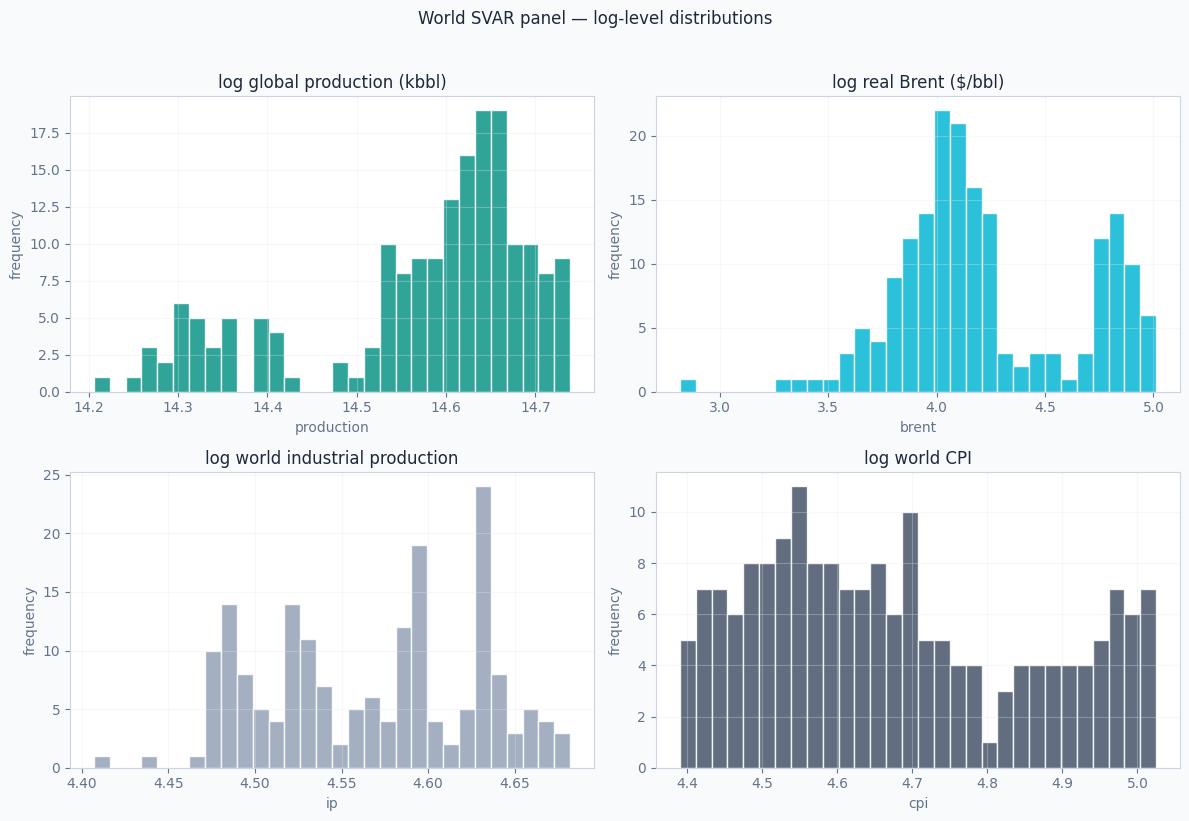

In [19]:
import matplotlib.pyplot as plt
from IPython.display import display

COLORS = {
    'bg': '#F8FAFC',
    'panel': '#FFFFFF',
    'text': '#1E293B',
    'muted': '#64748B',
    'grid': '#E2E8F0',
    'bars': ['#0D9488', '#06B6D4', '#94A3B8', '#475569'],
}

panel_log = world_panel.dropna()

stats = panel_log.describe().T
stats['skew'] = panel_log.skew()
stats['kurtosis'] = panel_log.kurtosis()
stats['missing'] = world_panel.isna().sum()
stats = stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis', 'missing']]

display(stats.round(3))

labels = {
    'brent': 'log real Brent ($/bbl)',
    'ip': 'log world industrial production',
    'cpi': 'log world CPI',
    'production': 'log global production (kbbl)',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.patch.set_facecolor(COLORS['bg'])
axes = axes.ravel()

for ax, col, color in zip(axes, panel_log.columns, COLORS['bars']):
    ax.set_facecolor(COLORS['panel'])
    ax.hist(panel_log[col].values, bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(labels.get(col, col), color=COLORS['text'])
    ax.set_xlabel(col, color=COLORS['muted'])
    ax.set_ylabel('frequency', color=COLORS['muted'])
    ax.grid(True, alpha=0.3, color=COLORS['grid'])

plt.suptitle('World SVAR panel — log-level distributions', color=COLORS['text'], y=1.02)
plt.tight_layout()
plt.show()

In [20]:
# doing an SVAR regression on the panel 
LAGS = 12 
Horizon = 36

var_model = VAR(world_panel) 
results = var_model.fit(LAGS, trend = 'c')

coef_mat = results.coefs  
resid_shocks = results.resid.to_numpy()
sigma_u = np.array(results.sigma_u) 

# performing a choleskly decomp to find the loadings 
shock_loads = np.linalg.cholesky(sigma_u)  

struct_shock = np.linalg.inv(shock_loads) @ resid_shocks.T

shocks = pd.DataFrame(struct_shock.T, columns = world_panel.columns, index = results.resid.index) 
shocks

,production,brent,ip,cpi
2012-01-01,-0.104739,0.398896,-0.010619,1.093216
2012-02-01,-0.639840,0.484203,0.395527,-0.900207
2012-03-01,-0.349780,0.551236,-1.196030,0.902925
2012-04-01,-0.086462,-0.542547,0.557214,0.034602
2012-05-01,-0.476038,-0.270085,0.373682,-0.241784
...,...,...,...,...
2025-10-01,1.224263,0.169736,0.066907,-0.168285
2025-11-01,0.678823,0.533256,0.367627,-0.783122
2025-12-01,0.244081,0.412687,-0.247746,-0.391567
2026-01-01,-0.652882,0.752812,-0.199283,-0.958536


In [21]:
n_var = coef_mat.shape[1]
psi = np.zeros((Horizon + 1, n_var, n_var))
psi[0] = np.eye(n_var)
structural_impulse_response = np.zeros((Horizon + 1, n_var, n_var))

for h in range(1, Horizon + 1):
    for lag in range(1, min(h, LAGS) + 1):
        psi[h] += coef_mat[lag - 1] @ psi[h - lag]   # was coef_mat[lag]
    structural_impulse_response[h] = psi[h] @ shock_loads

psi.shape

(37, 4, 4)

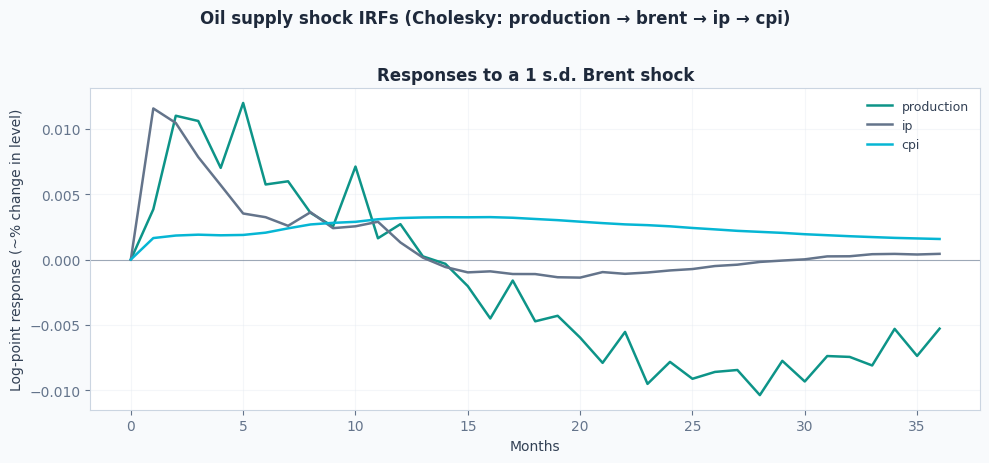

In [22]:
import matplotlib.pyplot as plt

COLORS = {
    'bg': '#F8FAFC',
    'panel': '#FFFFFF',
    'text': '#1E293B',
    'muted': '#64748B',
    'grid': '#E2E8F0',
    'lines': {'production': '#0D9488', 'cpi': '#06B6D4', 'ip': '#64748B'},
}

var_names = list(world_panel.columns)
brent_idx = var_names.index('brent')
response_vars = ['production', 'ip', 'cpi']
horizons = np.arange(Horizon + 1)

fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])
ax.axhline(0, color=COLORS['muted'], linewidth=0.8, alpha=0.6)

for resp in response_vars:
    resp_idx = var_names.index(resp)
    ax.plot(
        horizons,
        structural_impulse_response[:, resp_idx, brent_idx],
        color=COLORS['lines'][resp],
        linewidth=1.8,
        label=resp,
    )

ax.set_title('Responses to a 1 s.d. Brent shock', fontweight='600', color=COLORS['text'])
ax.set_xlabel('Months')
ax.set_ylabel('Log-point response (~% change in level)')
ax.grid(True, alpha=0.35, color=COLORS['grid'])
ax.legend(frameon=False, fontsize=9)

fig.suptitle(
    'Oil supply shock IRFs (Cholesky: production → brent → ip → cpi)',
    fontweight='600',
    y=1.02,
    color=COLORS['text'],
)
plt.tight_layout()
plt.show()

In [23]:
# Continental SVAR panels — same 4-variable spec as world_panel
continent_production = (
    production_df.groupby(['TIME_PERIOD', 'continent'])['OBS_VALUE']
    .sum()
    .unstack('continent')
)

# IMF CPI / CPB IP proxies (Africa & Oceania lack regional macro aggregates → world)
CONTINENT_CPI = {
    'Africa': 'world',
    'Asia': 'asia',
    'Europe': 'europe',
    'North America': 'americas',
    'Oceania': 'world',
    'South America': 'americas',
}
CONTINENT_IP = {
    'Africa': 'world',
    'Asia': 'china',
    'Europe': 'euro_area',
    'North America': 'united_states',
    'Oceania': 'world',
    'South America': 'latin_america',
}


def build_continent_panel(continent: str) -> pd.DataFrame:
    cpi_key = CONTINENT_CPI[continent]
    ip_key = CONTINENT_IP[continent]
    regional_cpi = cpi_index[cpi_key]
    brent_real = (brent_monthly / (regional_cpi / 100)).dropna()
    panel = pd.DataFrame({
        'brent': brent_real,
        'production': continent_production[continent],
        'cpi': regional_cpi,
        'ip': ip[ip_key],
    })[VAR_ORDER]
    return np.log(panel.dropna())


def fit_structural_irf(panel: pd.DataFrame, lags: int = LAGS, horizon: int = Horizon):
    results = VAR(panel).fit(lags, trend='c')
    coef_mat = results.coefs
    shock_loads = np.linalg.cholesky(np.array(results.sigma_u))
    n_var = coef_mat.shape[1]

    psi = np.zeros((horizon + 1, n_var, n_var))
    psi[0] = np.eye(n_var)
    structural_irf = np.zeros((horizon + 1, n_var, n_var))

    for h in range(1, horizon + 1):
        for lag in range(1, min(h, lags) + 1):
            psi[h] += coef_mat[lag - 1] @ psi[h - lag]
        structural_irf[h] = psi[h] @ shock_loads

    return results, structural_irf


continent_panels = {}
continent_irfs = {}
continent_var_results = {}

for continent in continent_production.columns:
    panel = build_continent_panel(continent)
    continent_panels[continent] = panel
    results, structural_irf = fit_structural_irf(panel)
    continent_var_results[continent] = results
    continent_irfs[continent] = structural_irf
    print(f"{continent}: {len(panel)} months, AIC={results.aic:.2f}")

list(continent_panels.keys())

Africa: 182 months, AIC=-30.68
Asia: 182 months, AIC=-29.91
Europe: 182 months, AIC=-27.94
North America: 182 months, AIC=-32.96
Oceania: 182 months, AIC=-30.94
South America: 182 months, AIC=-28.60


['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

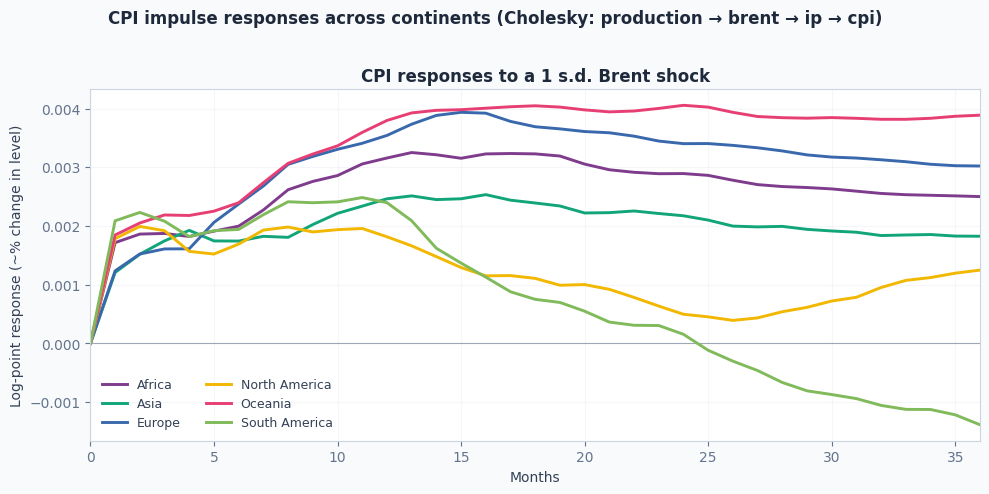

In [27]:
import matplotlib.pyplot as plt

COLORS = {
    'bg': '#F8FAFC',
    'panel': '#FFFFFF',
    'text': '#1E293B',
    'muted': '#64748B',
    'grid': '#E2E8F0',
    'lines': {'production': '#0D9488', 'cpi': '#06B6D4', 'ip': '#64748B'},
}
CONTINENT_COLORS = {
    'Africa': '#7F3C8D',
    'Asia': '#11A579',
    'Europe': '#3969AC',
    'North America': '#F2B701',
    'Oceania': '#E73F74',
    'South America': '#80BA5A',
}

var_names = list(VAR_ORDER)
brent_idx = var_names.index('brent')
cpi_idx = var_names.index('cpi')
horizons = np.arange(Horizon + 1)

all_cpi_responses = np.concatenate([
    structural_irf[:, cpi_idx, brent_idx].ravel()
    for structural_irf in continent_irfs.values()
])
y_padding = max(1e-6, 0.05 * (all_cpi_responses.max() - all_cpi_responses.min()))
ymin = min(all_cpi_responses.min() - y_padding, 0.0)
ymax = max(all_cpi_responses.max() + y_padding, 0.0)

fig, ax = plt.subplots(figsize=(10, 4.8))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])
ax.axhline(0, color=COLORS['muted'], linewidth=0.8, alpha=0.6)

for continent, structural_irf in continent_irfs.items():
    ax.plot(
        horizons,
        structural_irf[:, cpi_idx, brent_idx],
        linewidth=2.1,
        color=CONTINENT_COLORS.get(continent, COLORS['text']),
        label=continent,
    )

ax.set_xlim(horizons[0], horizons[-1])
ax.set_ylim(ymin, ymax)
ax.set_title('CPI responses to a 1 s.d. Brent shock', fontweight='600', color=COLORS['text'])
ax.set_xlabel('Months')
ax.set_ylabel('Log-point response (~% change in level)')
ax.grid(True, alpha=0.35, color=COLORS['grid'])
ax.legend(frameon=False, fontsize=9, ncol=2)
fig.suptitle(
    'CPI impulse responses across continents (Cholesky: production → brent → ip → cpi)',
    fontweight='600',
    y=1.02,
    color=COLORS['text'],
)
plt.tight_layout()
plt.show()

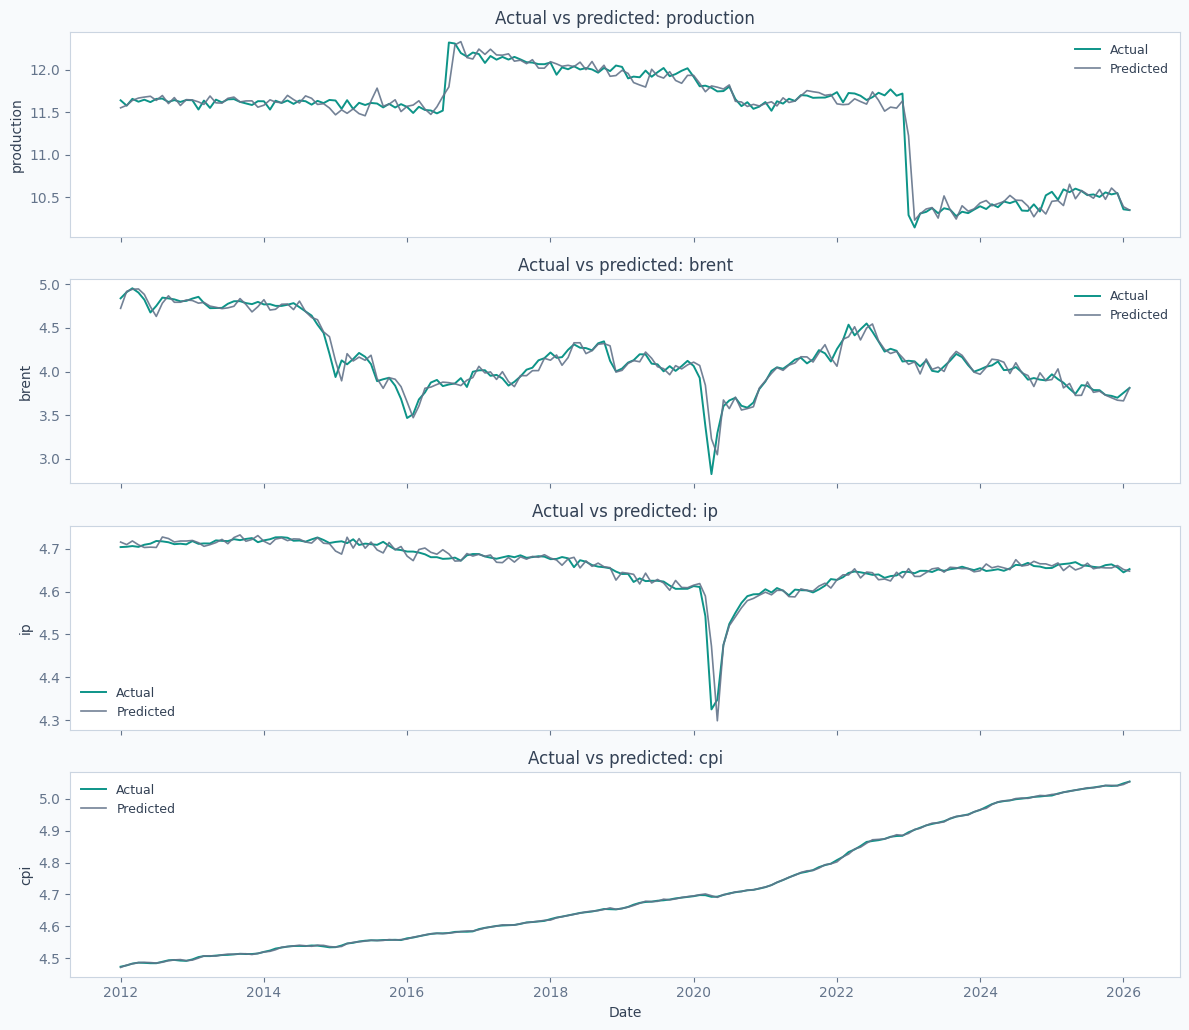

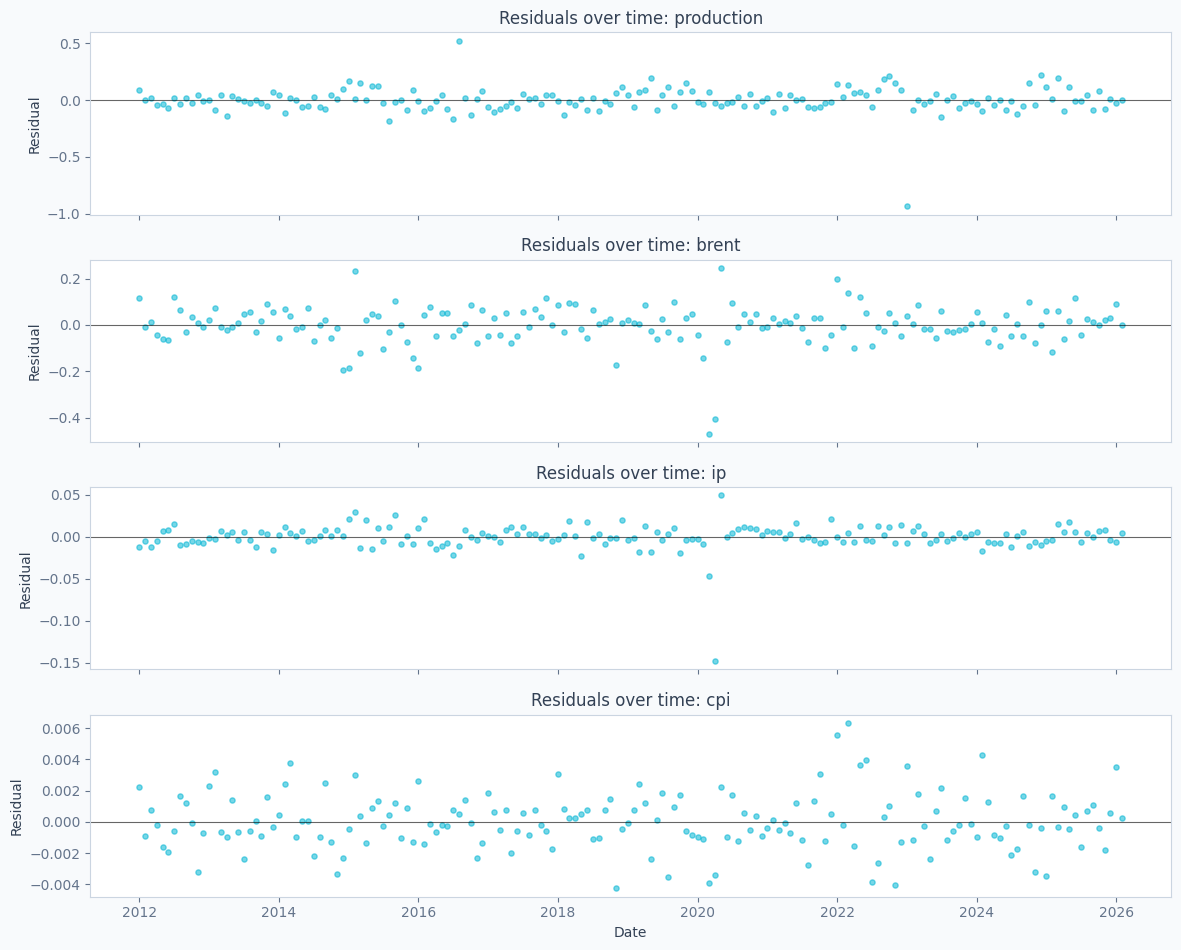

In [34]:
# now bootstrappingt the irfs 
fitted = results.fittedvalues
actual = pd.DataFrame(results.model.endog[results.k_ar:], index=fitted.index, columns=results.names)
if not isinstance(fitted, pd.DataFrame):
    fitted = pd.DataFrame(fitted, index=actual.index, columns=results.names)
residuals = pd.DataFrame(results.resid, index=fitted.index, columns=results.names)

fig, axes = plt.subplots(len(results.names), 1, figsize=(12, 2.6 * len(results.names)), sharex=True)
if len(results.names) == 1:
    axes = [axes]

for ax, col in zip(axes, results.names):
    ax.plot(actual.index, actual[col], label='Actual', color='#0D9488', linewidth=1.4)
    ax.plot(fitted.index, fitted[col], label='Predicted', color='#64748B', linewidth=1.2, alpha=0.9)
    ax.set_title(f'Actual vs predicted: {col}')
    ax.set_ylabel(col)
    ax.legend(frameon=False, fontsize=9)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(results.names), 1, figsize=(12, 2.4 * len(results.names)), sharex=True)
if len(results.names) == 1:
    axes = [axes]

for ax, col in zip(axes, results.names):
    ax.scatter(residuals.index, residuals[col], s=14, alpha=0.55, color='#06B6D4')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax.set_title(f'Residuals over time: {col}')
    ax.set_ylabel('Residual')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [62]:
# boostraping using the residuals 
resid_mean = residuals.mean(axis = 0 )
demean_residuals = residuals - resid_mean  
demean_residuals.head()
cov_matrix = np.cov(demean_residuals, rowvar = False)
print(cov_matrix)
# setting up a normal distribution that is multivariate normal 
# count the time
import time 
timer = time.time()

# now bootstrapping the irfs 
NUM_BOOTSTRAPS = 5000
results = {}
time_start = time.time()
for i in range(NUM_BOOTSTRAPS):
    
    rand_resids = np.random.multivariate_normal(np.zeros(world_panel.shape[1]), cov_matrix, size = len(world_panel))
    # now running the same SVAR 
    rand_panel = world_panel + rand_resids  
    rand_results, rand_irfs = fit_structural_irf(rand_panel)
    results[i] = (rand_results, rand_irfs)
time_end = time.time()
print(f"Bootstrap {i+1} completed in {time_end - time_start} seconds")
# finding out the standard deviation of the irfs

# finding out the standard deviation of the irfs  
irf_std = np.zeros((Horizon + 1, n_var, n_var))
for h in range(Horizon + 1): 
    for k in range(n_var) : 
        vals = np.array([results[i][1][h , k, :] for i in range(NUM_BOOTSTRAPS)])
        print(vals.shape)
        irf_std[h, k, :] = np.std(vals, axis=0)

    


[[ 1.25767260e-02 -3.69123884e-04 -3.43062447e-05 -3.03079404e-05]
 [-3.69123884e-04  7.10611177e-03  6.89620360e-04  7.30779388e-05]
 [-3.43062447e-05  6.89620360e-04  2.45354305e-04  5.35891342e-06]
 [-3.03079404e-05  7.30779388e-05  5.35891342e-06  3.24577334e-06]]
Bootstrap 5000 completed in 9.417563915252686 seconds
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 4)
(5000, 

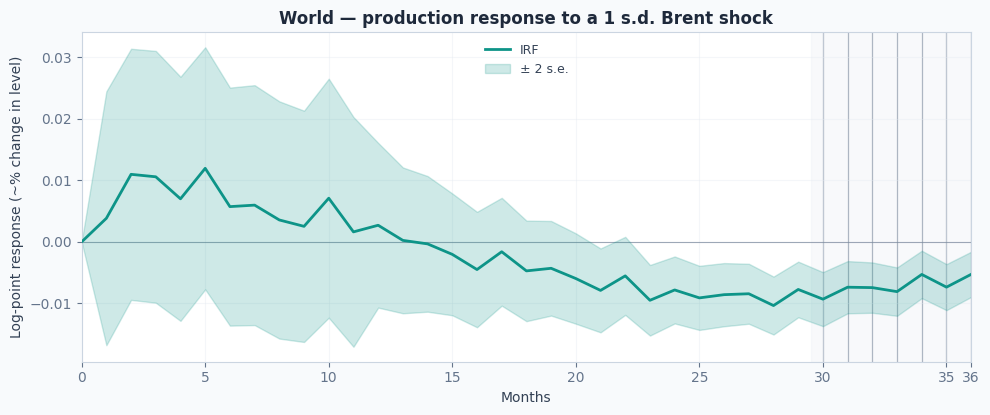

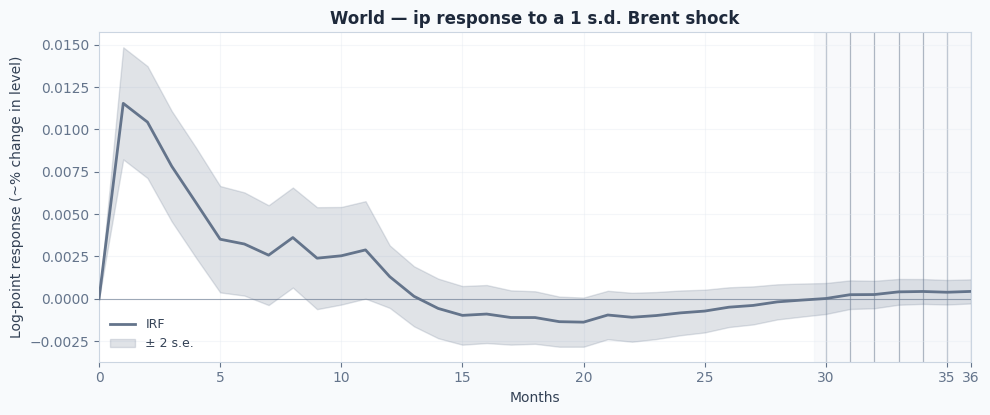

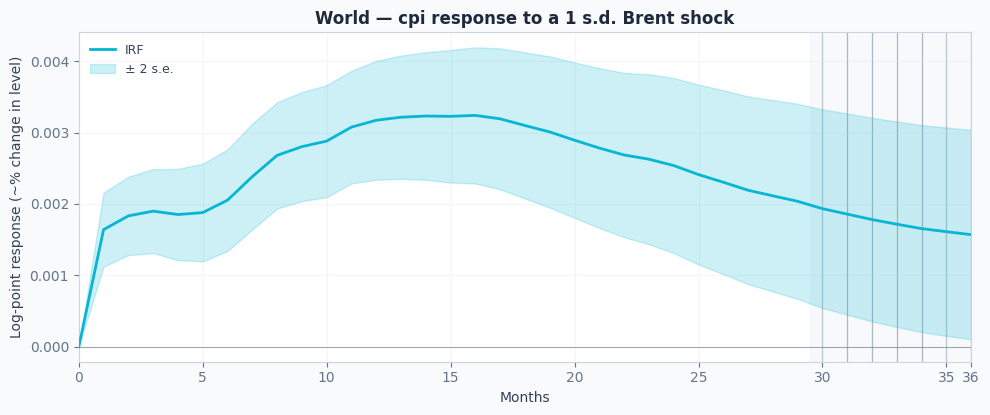

In [ ]:
# World IRFs with ±2 s.e. bands (uses structural_impulse_response and irf_std from bootstrap cell above)
var_names = list(world_panel.columns)
brent_idx = var_names.index('brent')
response_vars = ['production', 'ip', 'cpi']
horizons = np.arange(Horizon + 1)

for resp in response_vars:
    resp_idx = var_names.index(resp)
    irf_series = structural_impulse_response[:, resp_idx, brent_idx]
    std_band = 2.0 * irf_std[:, resp_idx, brent_idx]

    fig, ax = plt.subplots(figsize=(10, 4.25))
    fig.patch.set_facecolor(COLORS['bg'])
    ax.set_facecolor(COLORS['panel'])
    ax.axhline(0, color=COLORS['muted'], linewidth=0.8, alpha=0.6)
    tail_start = max(0, Horizon - 6)
    ax.axvspan(tail_start - 0.5, Horizon + 0.5, color=COLORS['grid'], alpha=0.22, zorder=0)
    for month in range(tail_start, Horizon + 1):
        ax.axvline(month, color=COLORS['muted'], linewidth=0.9, alpha=0.5, zorder=0)
    ax.plot(horizons, irf_series, color=COLORS['lines'][resp], linewidth=2.0, label='IRF', zorder=3)
    ax.fill_between(horizons, irf_series - std_band, irf_series + std_band, color=COLORS['lines'][resp], alpha=0.20, label='± 2 s.e.', zorder=2)
    ax.set_xlim(0, Horizon)
    xticks = list(np.arange(0, Horizon + 1, 5))
    if Horizon not in xticks:
        xticks.append(Horizon)
    ax.set_xticks(xticks)
    ax.set_title(f'World — {resp} response to a 1 s.d. Brent shock', fontweight='600', color=COLORS['text'])
    ax.set_xlabel('Months')
    ax.set_ylabel('Log-point response (~% change in level)')
    ax.grid(True, alpha=0.35, color=COLORS['grid'])
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()


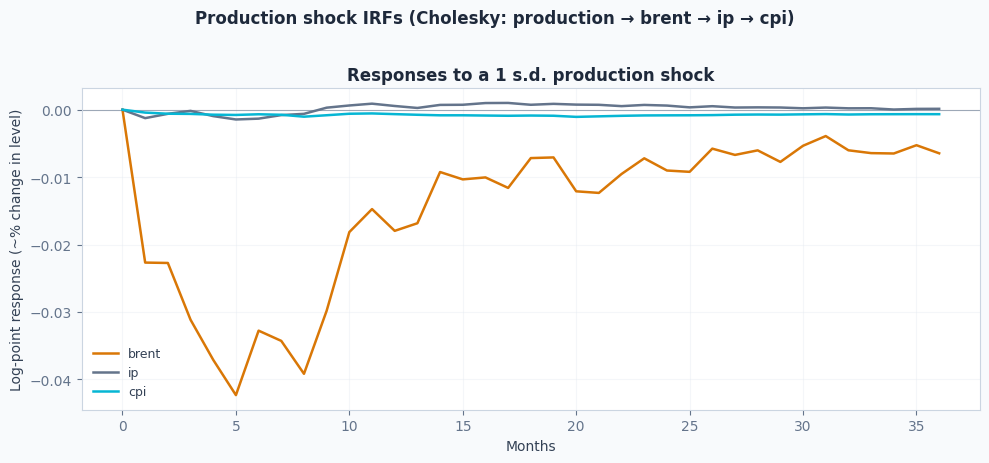

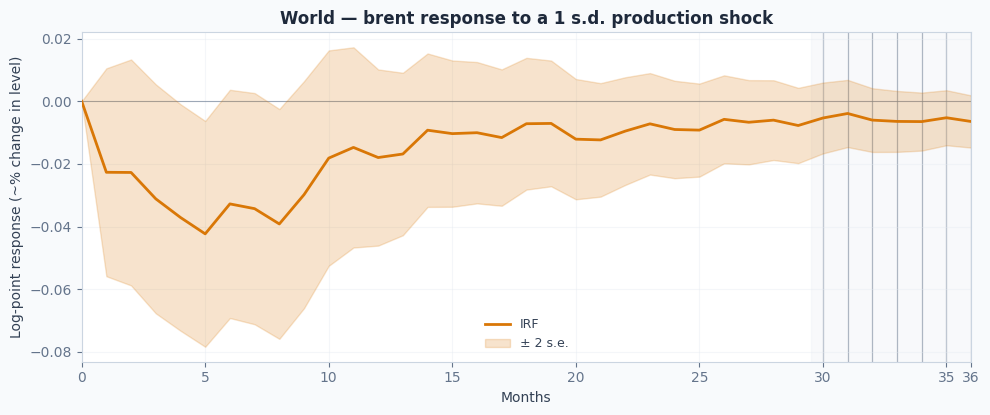

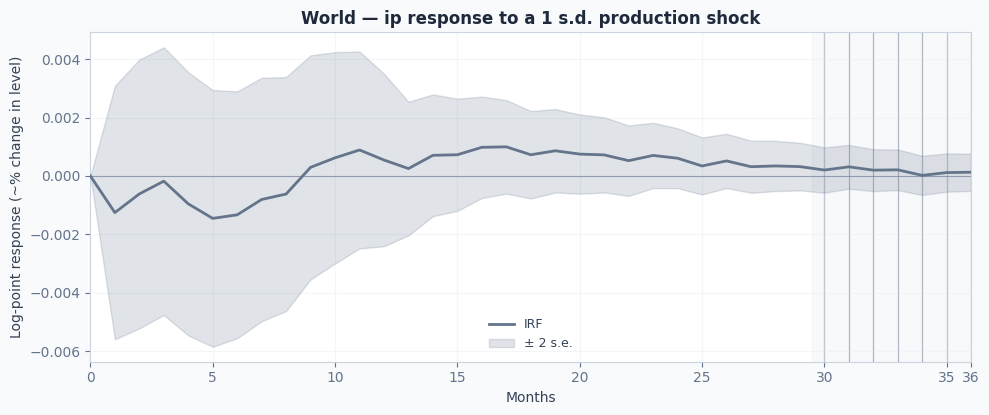

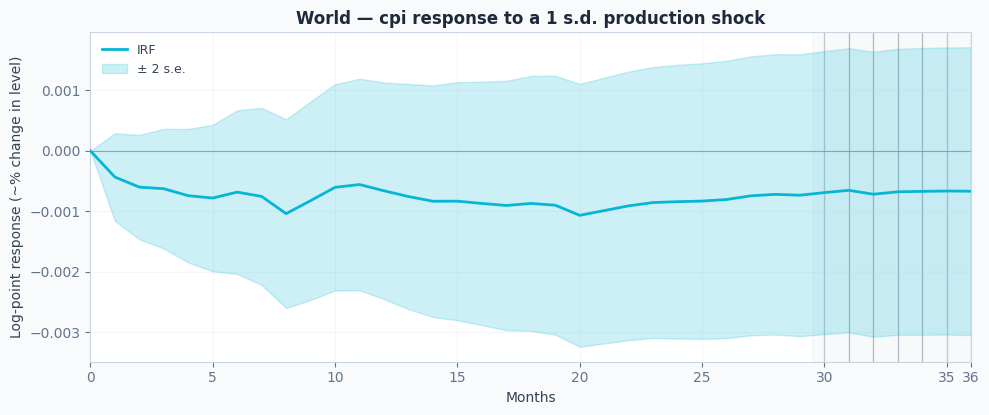

In [65]:
# World IRFs — production shock (uses structural_impulse_response and irf_std from bootstrap cell above)
var_names = list(world_panel.columns)
prod_idx = var_names.index('production')
prod_response_vars = ['brent', 'ip', 'cpi']
horizons = np.arange(Horizon + 1)

prod_colors = {
    'bg': '#F8FAFC',
    'panel': '#FFFFFF',
    'text': '#1E293B',
    'muted': '#64748B',
    'grid': '#E2E8F0',
    'lines': {'brent': '#D97706', 'cpi': '#06B6D4', 'ip': '#64748B'},
}

fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor(prod_colors['bg'])
ax.set_facecolor(prod_colors['panel'])
ax.axhline(0, color=prod_colors['muted'], linewidth=0.8, alpha=0.6)

for resp in prod_response_vars:
    resp_idx = var_names.index(resp)
    ax.plot(
        horizons,
        structural_impulse_response[:, resp_idx, prod_idx],
        color=prod_colors['lines'][resp],
        linewidth=1.8,
        label=resp,
    )

ax.set_title('Responses to a 1 s.d. production shock', fontweight='600', color=prod_colors['text'])
ax.set_xlabel('Months')
ax.set_ylabel('Log-point response (~% change in level)')
ax.grid(True, alpha=0.35, color=prod_colors['grid'])
ax.legend(frameon=False, fontsize=9)
fig.suptitle(
    'Production shock IRFs (Cholesky: production → brent → ip → cpi)',
    fontweight='600',
    y=1.02,
    color=prod_colors['text'],
)
plt.tight_layout()
plt.show()

for resp in prod_response_vars:
    resp_idx = var_names.index(resp)
    irf_series = structural_impulse_response[:, resp_idx, prod_idx]
    std_band = 2.0 * irf_std[:, resp_idx, prod_idx]

    fig, ax = plt.subplots(figsize=(10, 4.25))
    fig.patch.set_facecolor(prod_colors['bg'])
    ax.set_facecolor(prod_colors['panel'])
    ax.axhline(0, color=prod_colors['muted'], linewidth=0.8, alpha=0.6)
    tail_start = max(0, Horizon - 6)
    ax.axvspan(tail_start - 0.5, Horizon + 0.5, color=prod_colors['grid'], alpha=0.22, zorder=0)
    for month in range(tail_start, Horizon + 1):
        ax.axvline(month, color=prod_colors['muted'], linewidth=0.9, alpha=0.5, zorder=0)
    ax.plot(horizons, irf_series, color=prod_colors['lines'][resp], linewidth=2.0, label='IRF', zorder=3)
    ax.fill_between(
        horizons,
        irf_series - std_band,
        irf_series + std_band,
        color=prod_colors['lines'][resp],
        alpha=0.20,
        label='± 2 s.e.',
        zorder=2,
    )
    ax.set_xlim(0, Horizon)
    xticks = list(np.arange(0, Horizon + 1, 5))
    if Horizon not in xticks:
        xticks.append(Horizon)
    ax.set_xticks(xticks)
    ax.set_title(
        f'World — {resp} response to a 1 s.d. production shock',
        fontweight='600',
        color=prod_colors['text'],
    )
    ax.set_xlabel('Months')
    ax.set_ylabel('Log-point response (~% change in level)')
    ax.grid(True, alpha=0.35, color=prod_colors['grid'])
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

Africa: bootstrap completed in 10.8 seconds


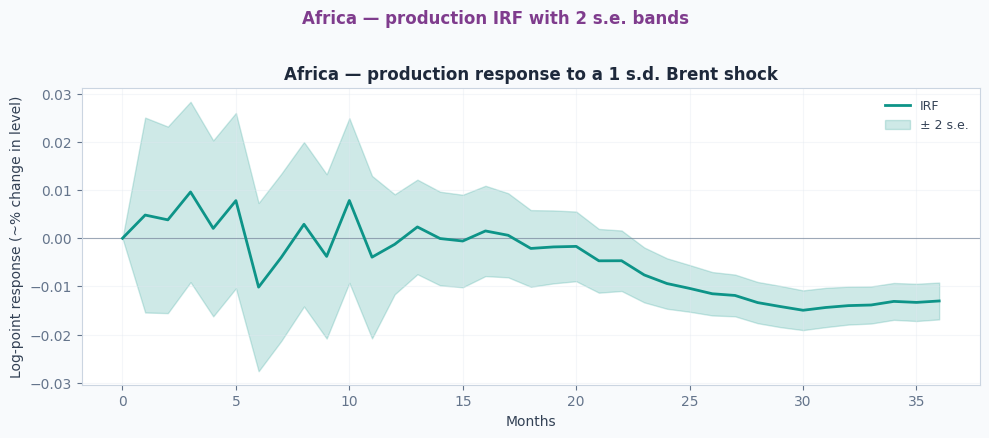

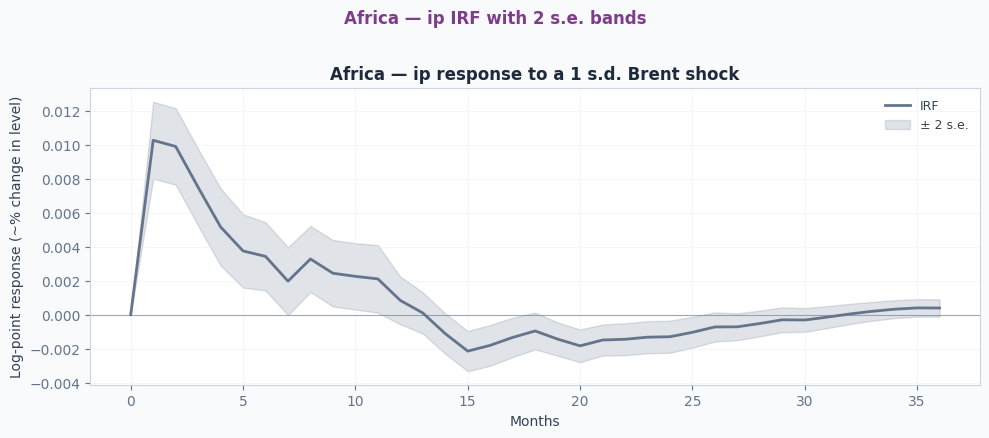

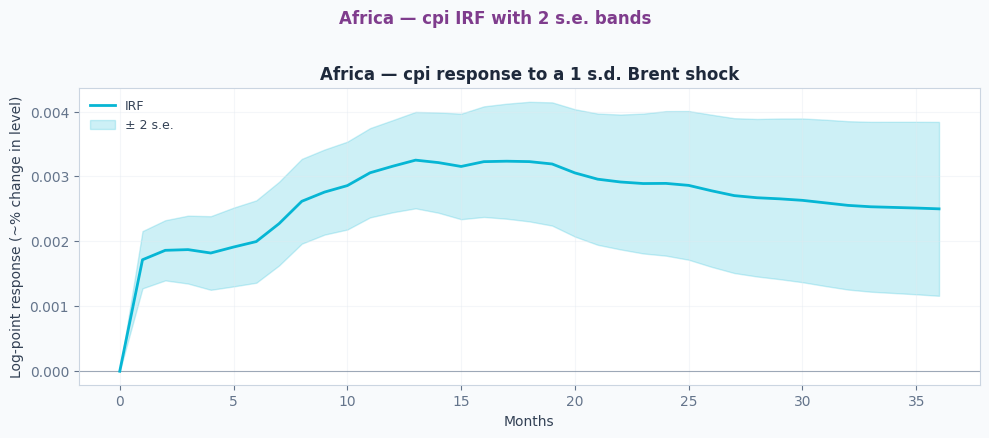

Asia: bootstrap completed in 12.5 seconds


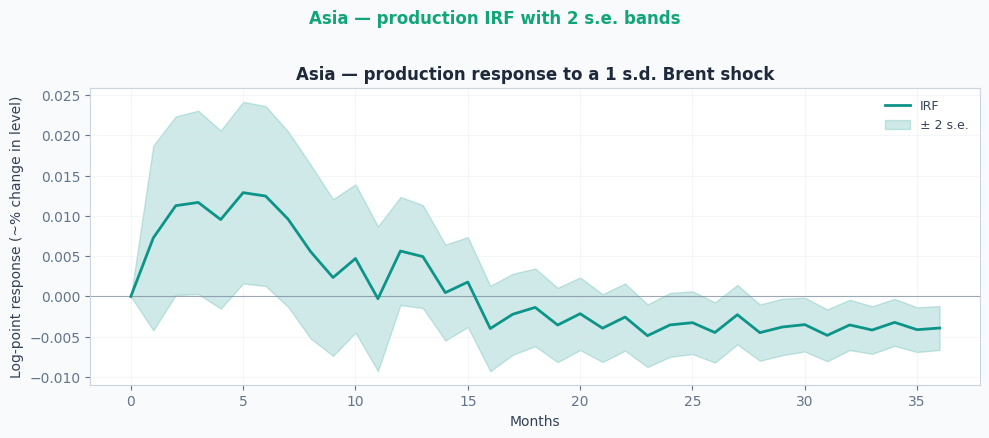

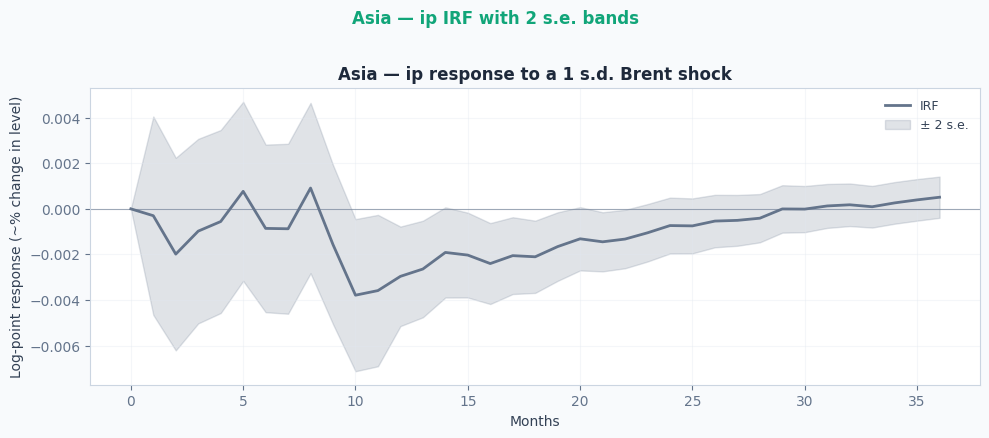

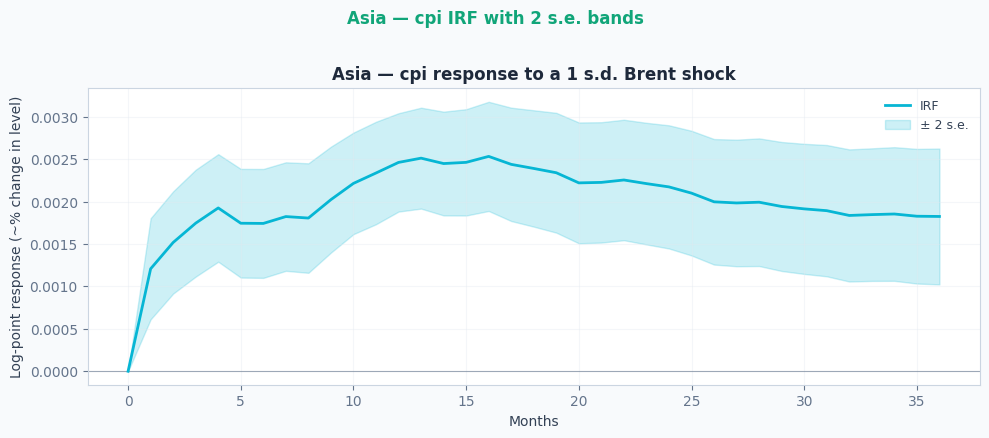

Europe: bootstrap completed in 9.6 seconds


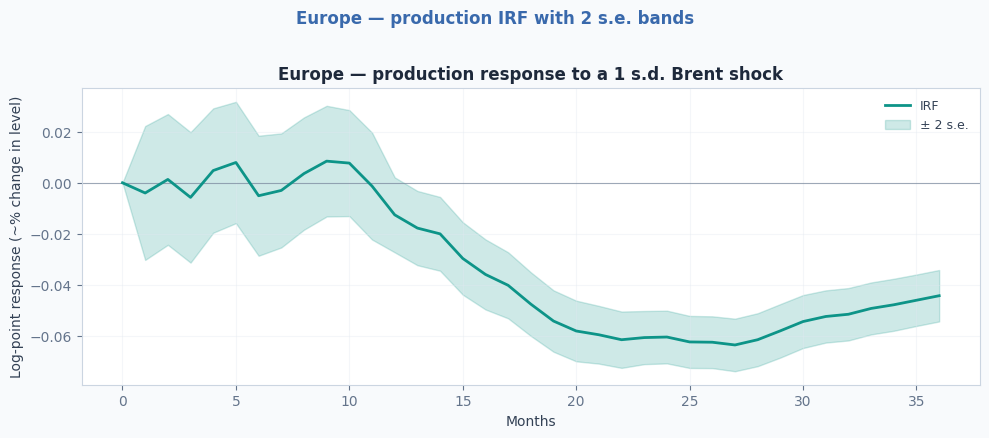

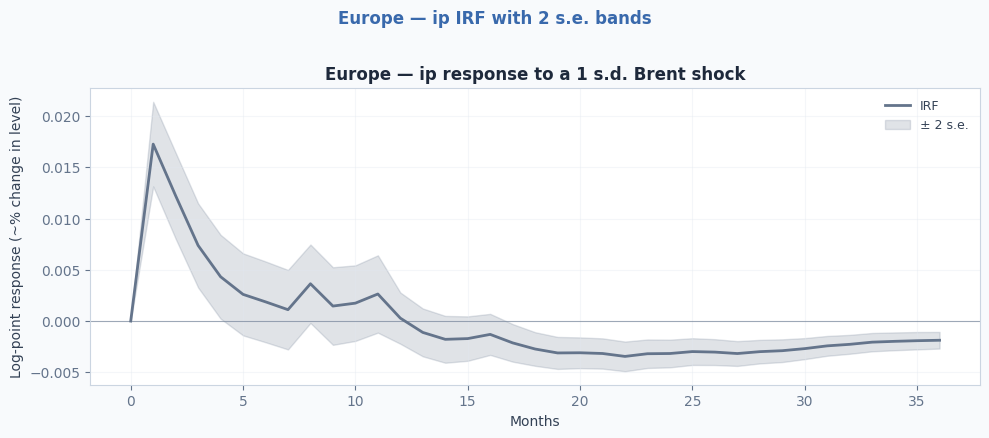

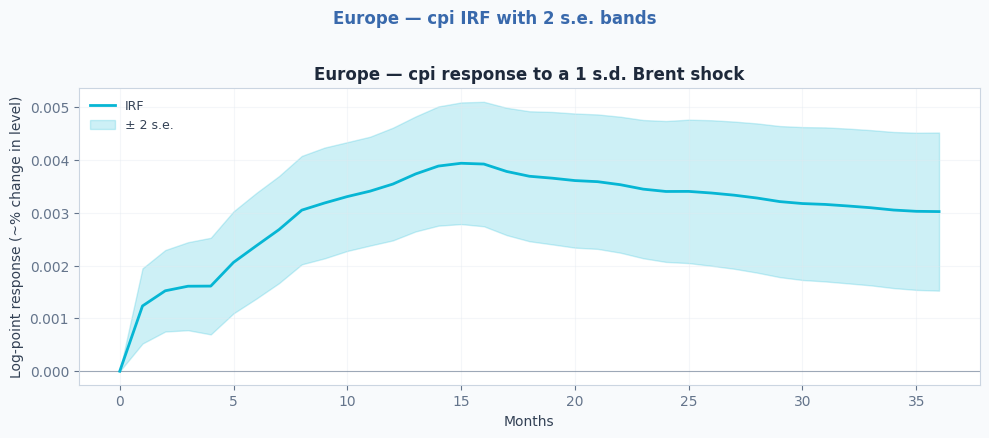

North America: bootstrap completed in 8.5 seconds


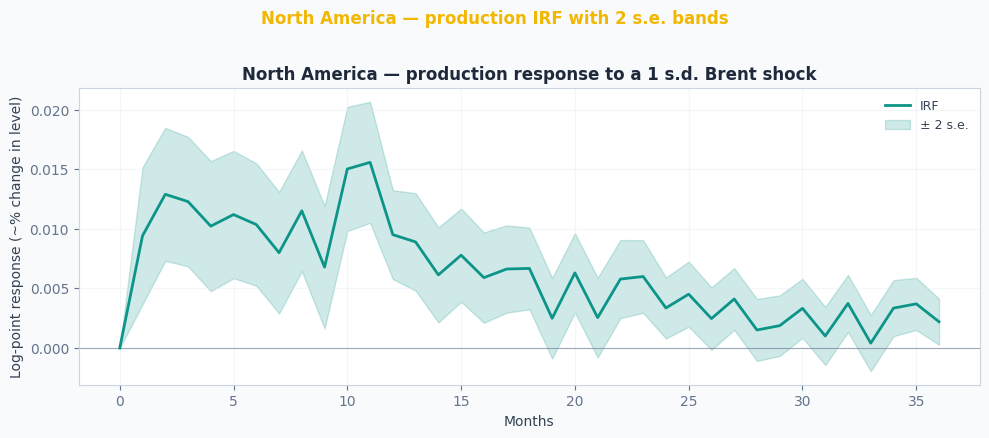

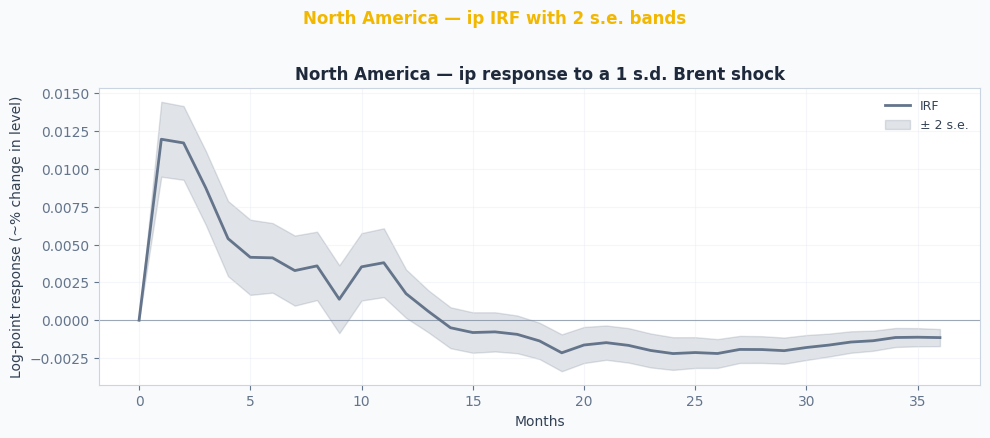

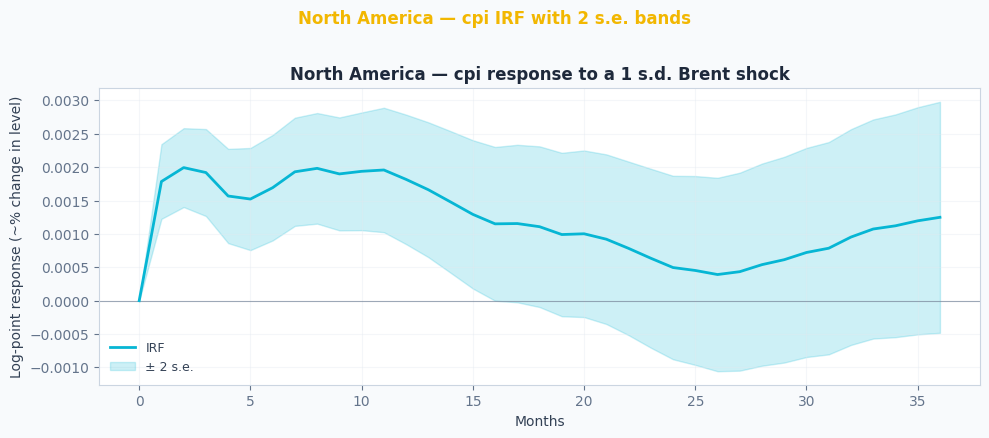

Oceania: bootstrap completed in 8.6 seconds


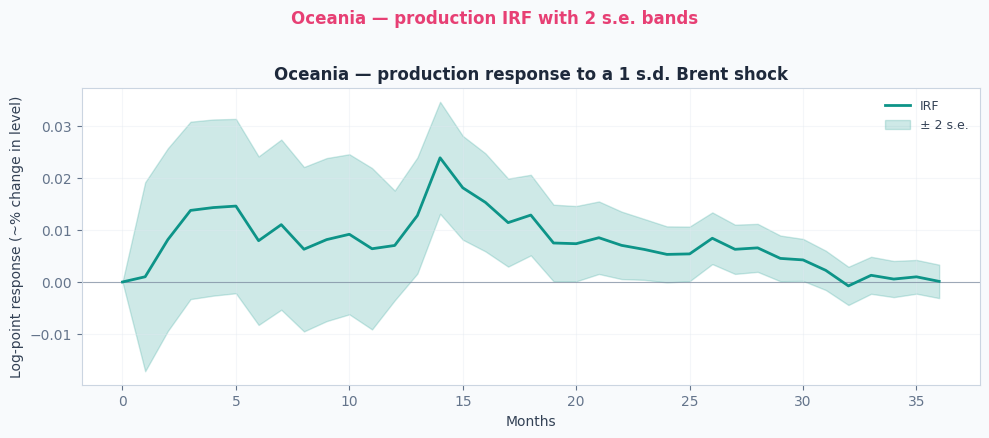

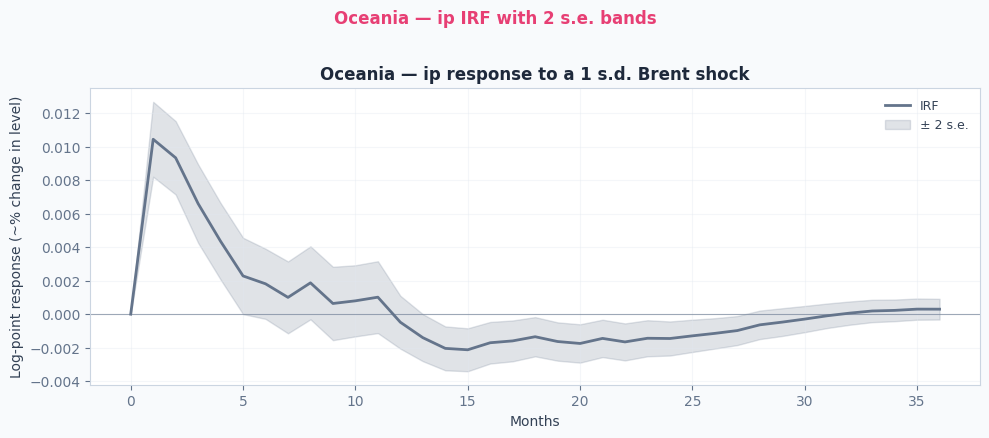

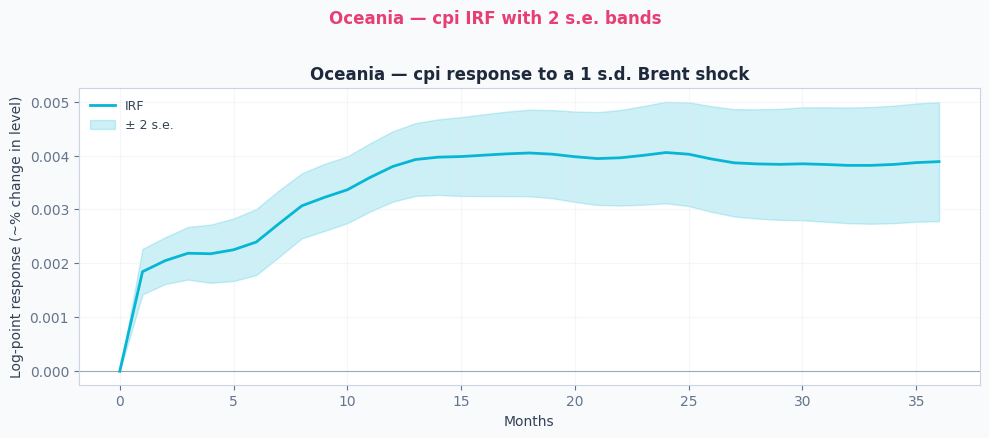

South America: bootstrap completed in 8.9 seconds


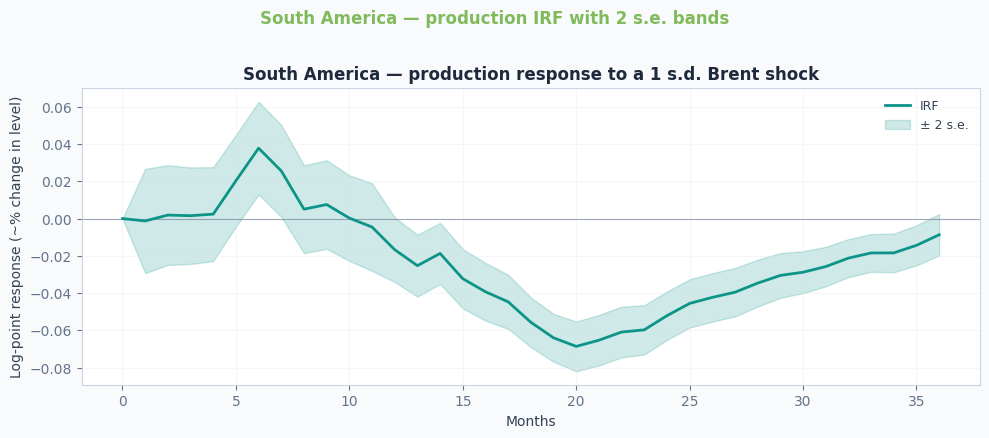

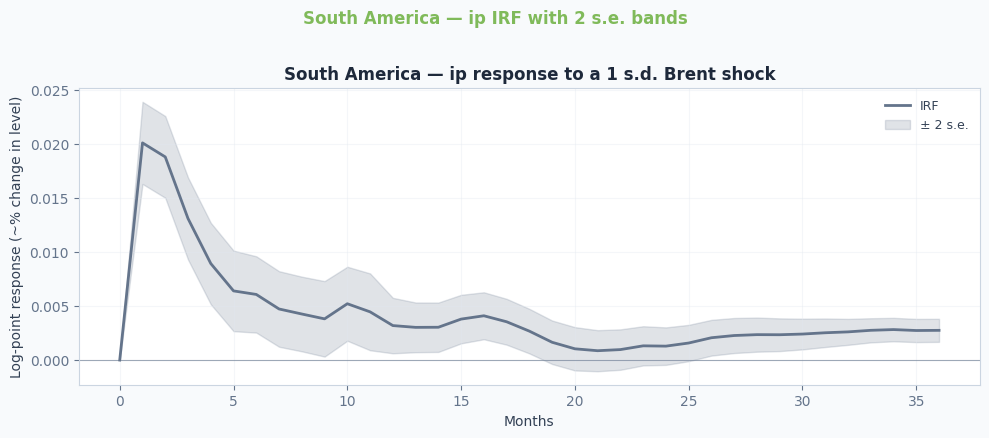

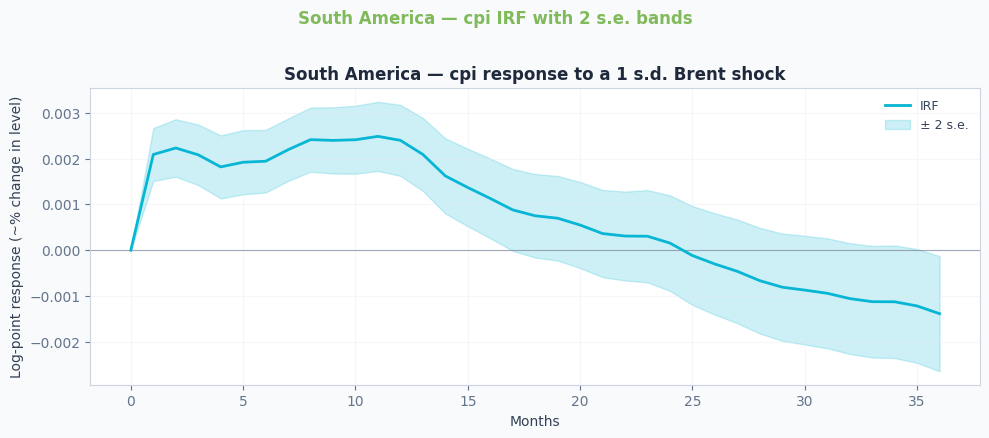

In [60]:
# Continental bootstrap IRFs (inline, same pattern as world bootstrap above)
continent_irf_std = {}

for continent in continent_panels:
    cont_panel = continent_panels[continent]
    cont_results = continent_var_results[continent]
    cont_n_var = cont_panel.shape[1]

    cont_resid_mean = cont_results.resid.mean(axis=0)
    cont_demean_residuals = cont_results.resid - cont_resid_mean
    cont_cov_matrix = np.cov(cont_demean_residuals, rowvar=False)

    cont_bootstrap_results = {}
    time_start = time.time()
    for i in range(NUM_BOOTSTRAPS):
        rand_resids = np.random.multivariate_normal(
            np.zeros(cont_panel.shape[1]),
            cont_cov_matrix,
            size=len(cont_panel),
        )
        rand_panel = cont_panel + rand_resids
        rand_results, rand_irfs = fit_structural_irf(rand_panel)
        cont_bootstrap_results[i] = (rand_results, rand_irfs)
    time_end = time.time()
    print(f'{continent}: bootstrap completed in {time_end - time_start:.1f} seconds')

    cont_irf_std = np.zeros((Horizon + 1, cont_n_var, cont_n_var))
    for h in range(Horizon + 1):
        for k in range(cont_n_var):
            vals = np.array([cont_bootstrap_results[i][1][h, k, :] for i in range(NUM_BOOTSTRAPS)])
            cont_irf_std[h, k, :] = np.std(vals, axis=0)
    continent_irf_std[continent] = cont_irf_std

    var_names = list(cont_panel.columns)
    brent_idx = var_names.index('brent')
    actual_irf = continent_irfs[continent]

    for resp in response_vars:
        resp_idx = var_names.index(resp)
        irf_series = actual_irf[:, resp_idx, brent_idx]
        std_band = 2.0 * cont_irf_std[:, resp_idx, brent_idx]

        fig, ax = plt.subplots(figsize=(10, 4.25))
        fig.patch.set_facecolor(COLORS['bg'])
        ax.set_facecolor(COLORS['panel'])
        ax.axhline(0, color=COLORS['muted'], linewidth=0.8, alpha=0.6)
        tail_start = max(0, Horizon - 6)
        ax.axvspan(tail_start - 0.5, Horizon + 0.5, color=COLORS['grid'], alpha=0.22, zorder=0)
        for month in range(tail_start, Horizon + 1):
            ax.axvline(month, color=COLORS['muted'], linewidth=0.9, alpha=0.5, zorder=0)
        ax.plot(horizons, irf_series, color=COLORS['lines'][resp], linewidth=2.0, label='IRF', zorder=3)
        ax.fill_between(horizons, irf_series - std_band, irf_series + std_band, color=COLORS['lines'][resp], alpha=0.20, label='± 2 s.e.', zorder=2)
        ax.set_xlim(0, Horizon)
        xticks = list(np.arange(0, Horizon + 1, 5))
        if Horizon not in xticks:
            xticks.append(Horizon)
        ax.set_xticks(xticks)
        ax.set_title(f'{continent} — {resp} response to a 1 s.d. Brent shock', fontweight='600', color=COLORS['text'])
        ax.set_xlabel('Months')
        ax.set_ylabel('Log-point response (~% change in level)')
        ax.grid(True, alpha=0.35, color=COLORS['grid'])
        ax.legend(frameon=False, fontsize=9)
        fig.suptitle(
            f'{continent} — {resp} IRF with 2 s.e. bands',
            fontweight='600',
            y=1.02,
            color=CONTINENT_COLORS.get(continent, COLORS['text']),
        )
        plt.tight_layout()
        plt.show()


In [50]:
results[0][1].shape

(37, 4, 4)

In [38]:
Horizon, n_var

(36, 4)